In [226]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


# Exercise 3


### 3.1


![ex3_1.png](ex3_1.png)

Time series 1:
* II.C

Time series 2:
* I.A

Time series 3:
* III.B


### 3.2

![ex3_2.png](ex3_2.png)

##### 3.2.a


* Most likely just white noise or more generally just some measurement noise, namely some constant mean $\mu$ which the samples vary around with constant variation $\sigma^2$, and there is no reason to believe in any dependence in time (if the machine works)

##### 3.2.b

In [227]:
dd <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/kreatin.dat")
d.creatine <- as.numeric(dd["V2"][2:nrow(dd),1])

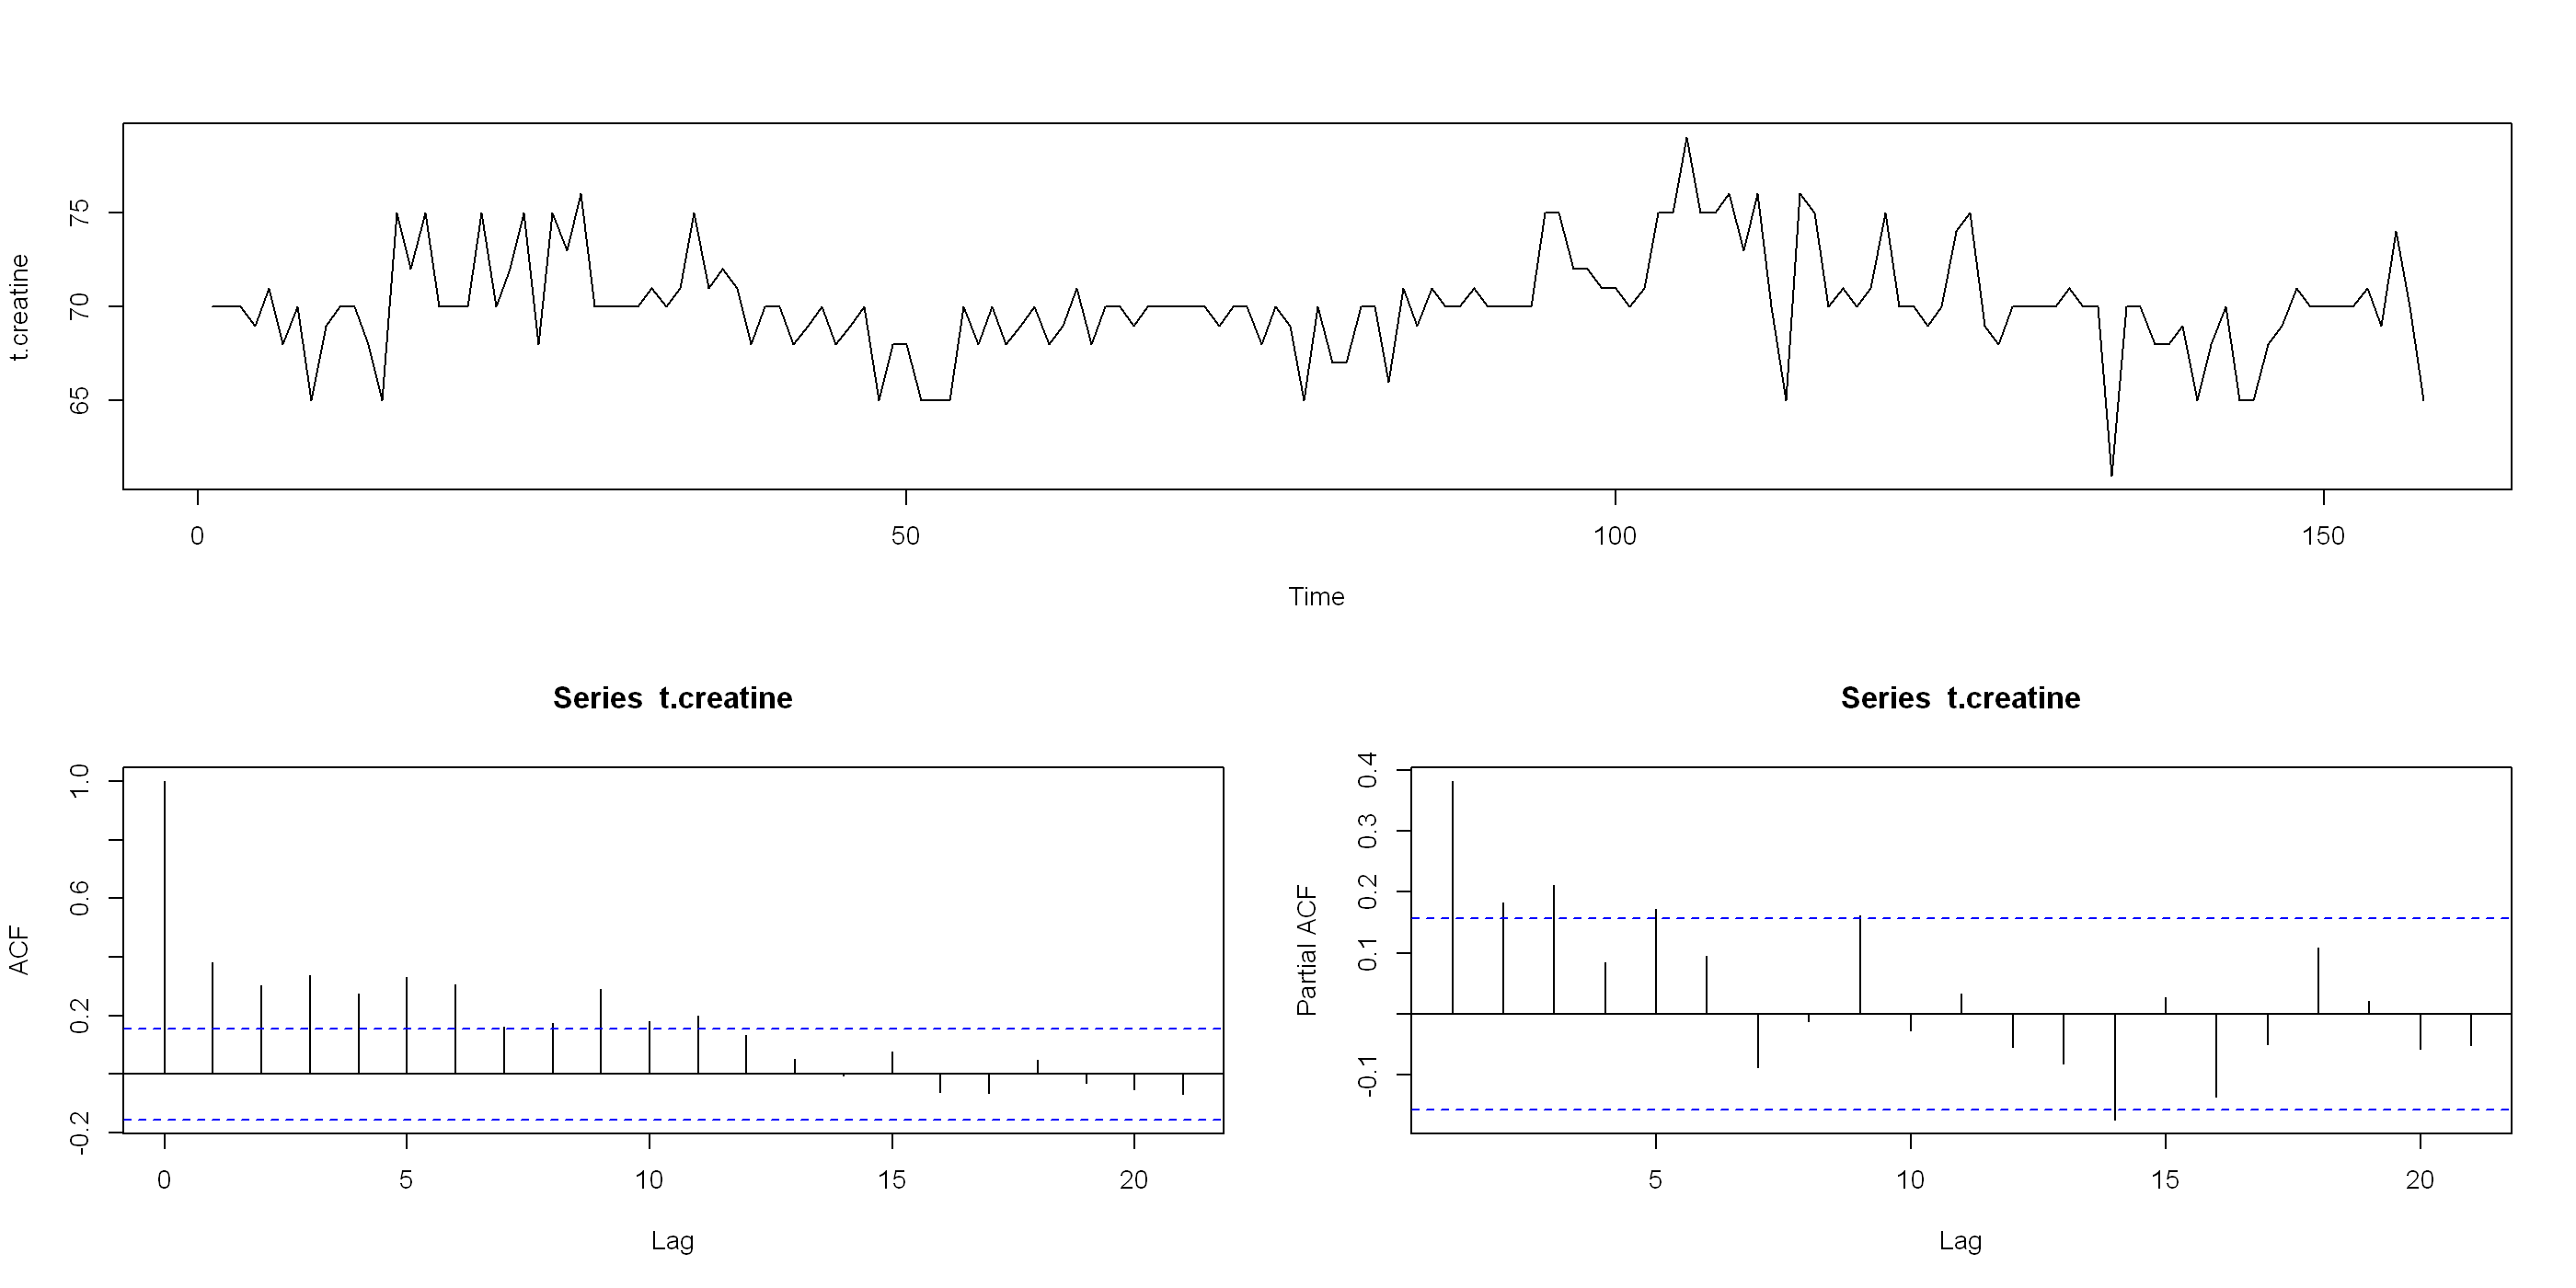

In [228]:
t.creatine <- ts(d.creatine)
layout(matrix(c(1, 1,2, 3), nrow = 2, byrow = TRUE))
plot(t.creatine)
acf(t.creatine)
pacf(t.creatine)

* It is rather obvious that there is a serial correlation, though not great, it strongly suggests that the machine is not working adequetely, almost as if there are some data/sample leakage in time, that is sample in at time t affects the sample at time t+1, which is ofcourse nonsense.

### 3.3


![ex3_3.png](ex3_3.png)

In [229]:
d.force <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/kraft.dat",header = FALSE)
ts.force <- ts(d.force[,1])
str(ts.force)

 Time-Series [1:320] from 1 to 320: -0.103 0.183 0.241 0.281 0.298 0.065 0.102 0.143 -0.029 -0.083 ...


##### 3.3.a

The periodic behaviour is expected as hinted, waves in a closed environment like this, is expected to correspond to periodic behaviour in the time series with approximately same period as the waves.

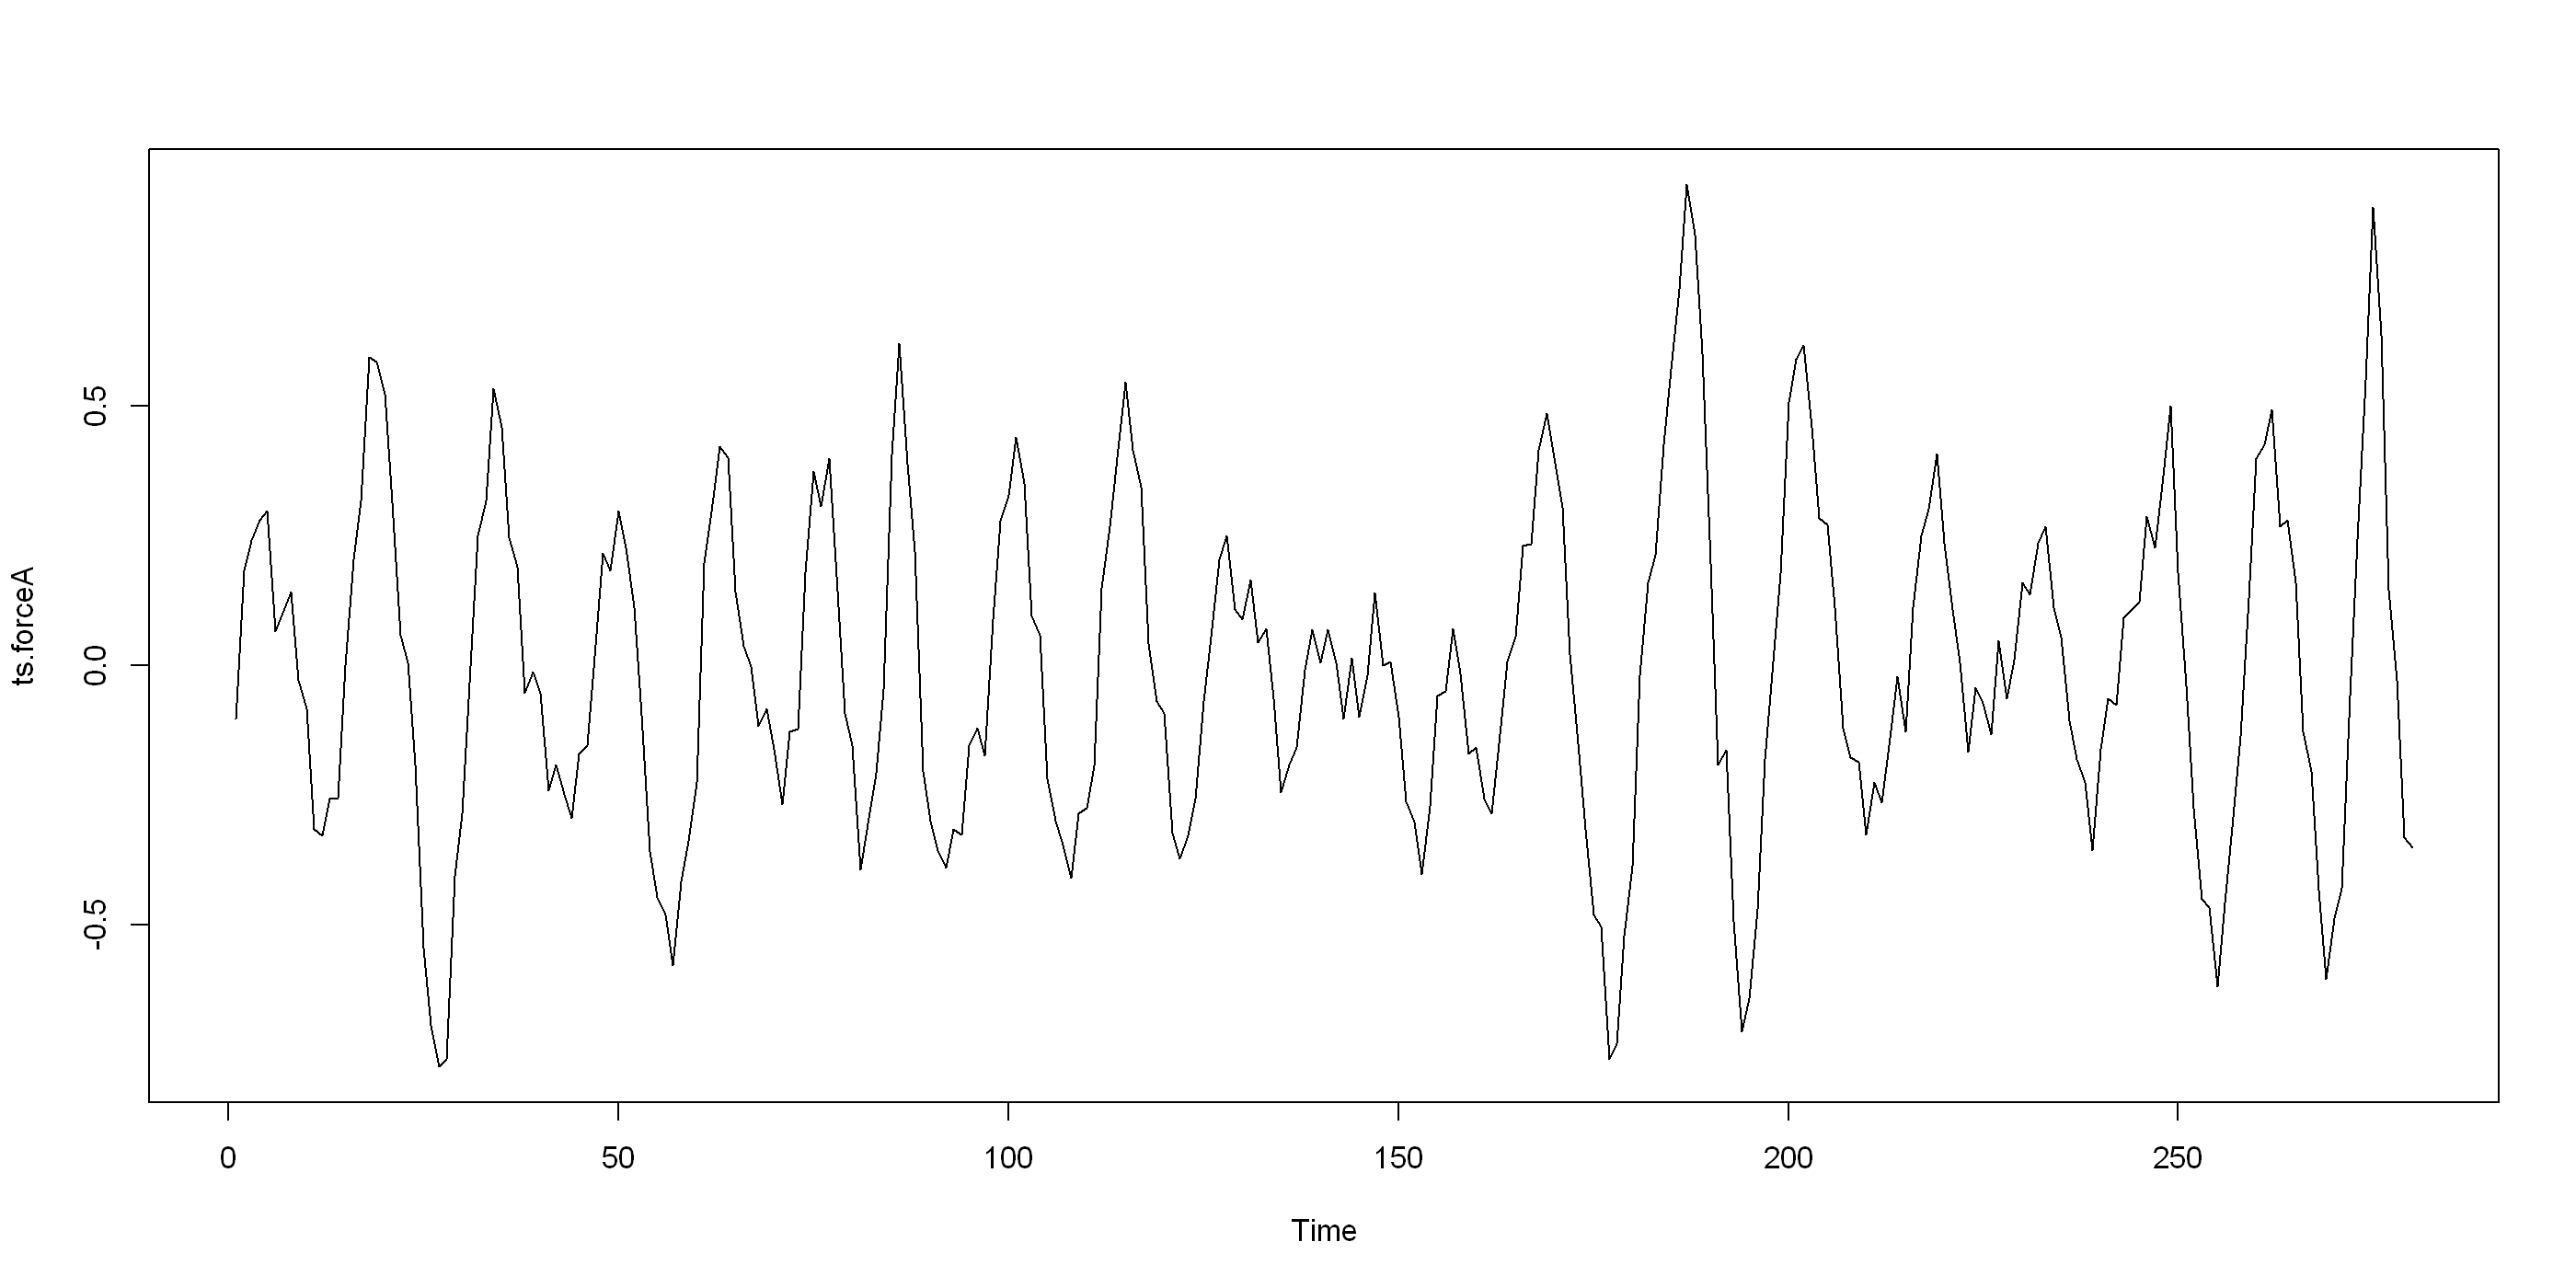

In [326]:
ts.forceA <- window(ts.force,end=280)
plot(ts.forceA)

Approximately 4 peaks every 50 timestep, hence the period is about 12.5 time units which gives the period of $\approx 12.5 * 0.15 s \approx 1.9s$, indeed a period of around 2s, notably it is not super strong though.

##### 3.3.b


Partial autocorrelations of series 'ts.forceA', by lag

     1      2      3      4      5      6      7      8      9     10     11 
 0.860 -0.541 -0.374 -0.421  0.293 -0.423 -0.009 -0.024 -0.206  0.131 -0.072 
    12     13     14     15     16     17     18     19     20     21     22 
-0.060  0.106 -0.113  0.027  0.021 -0.143  0.059  0.032  0.029  0.065 -0.036 
    23     24 
 0.016  0.079 


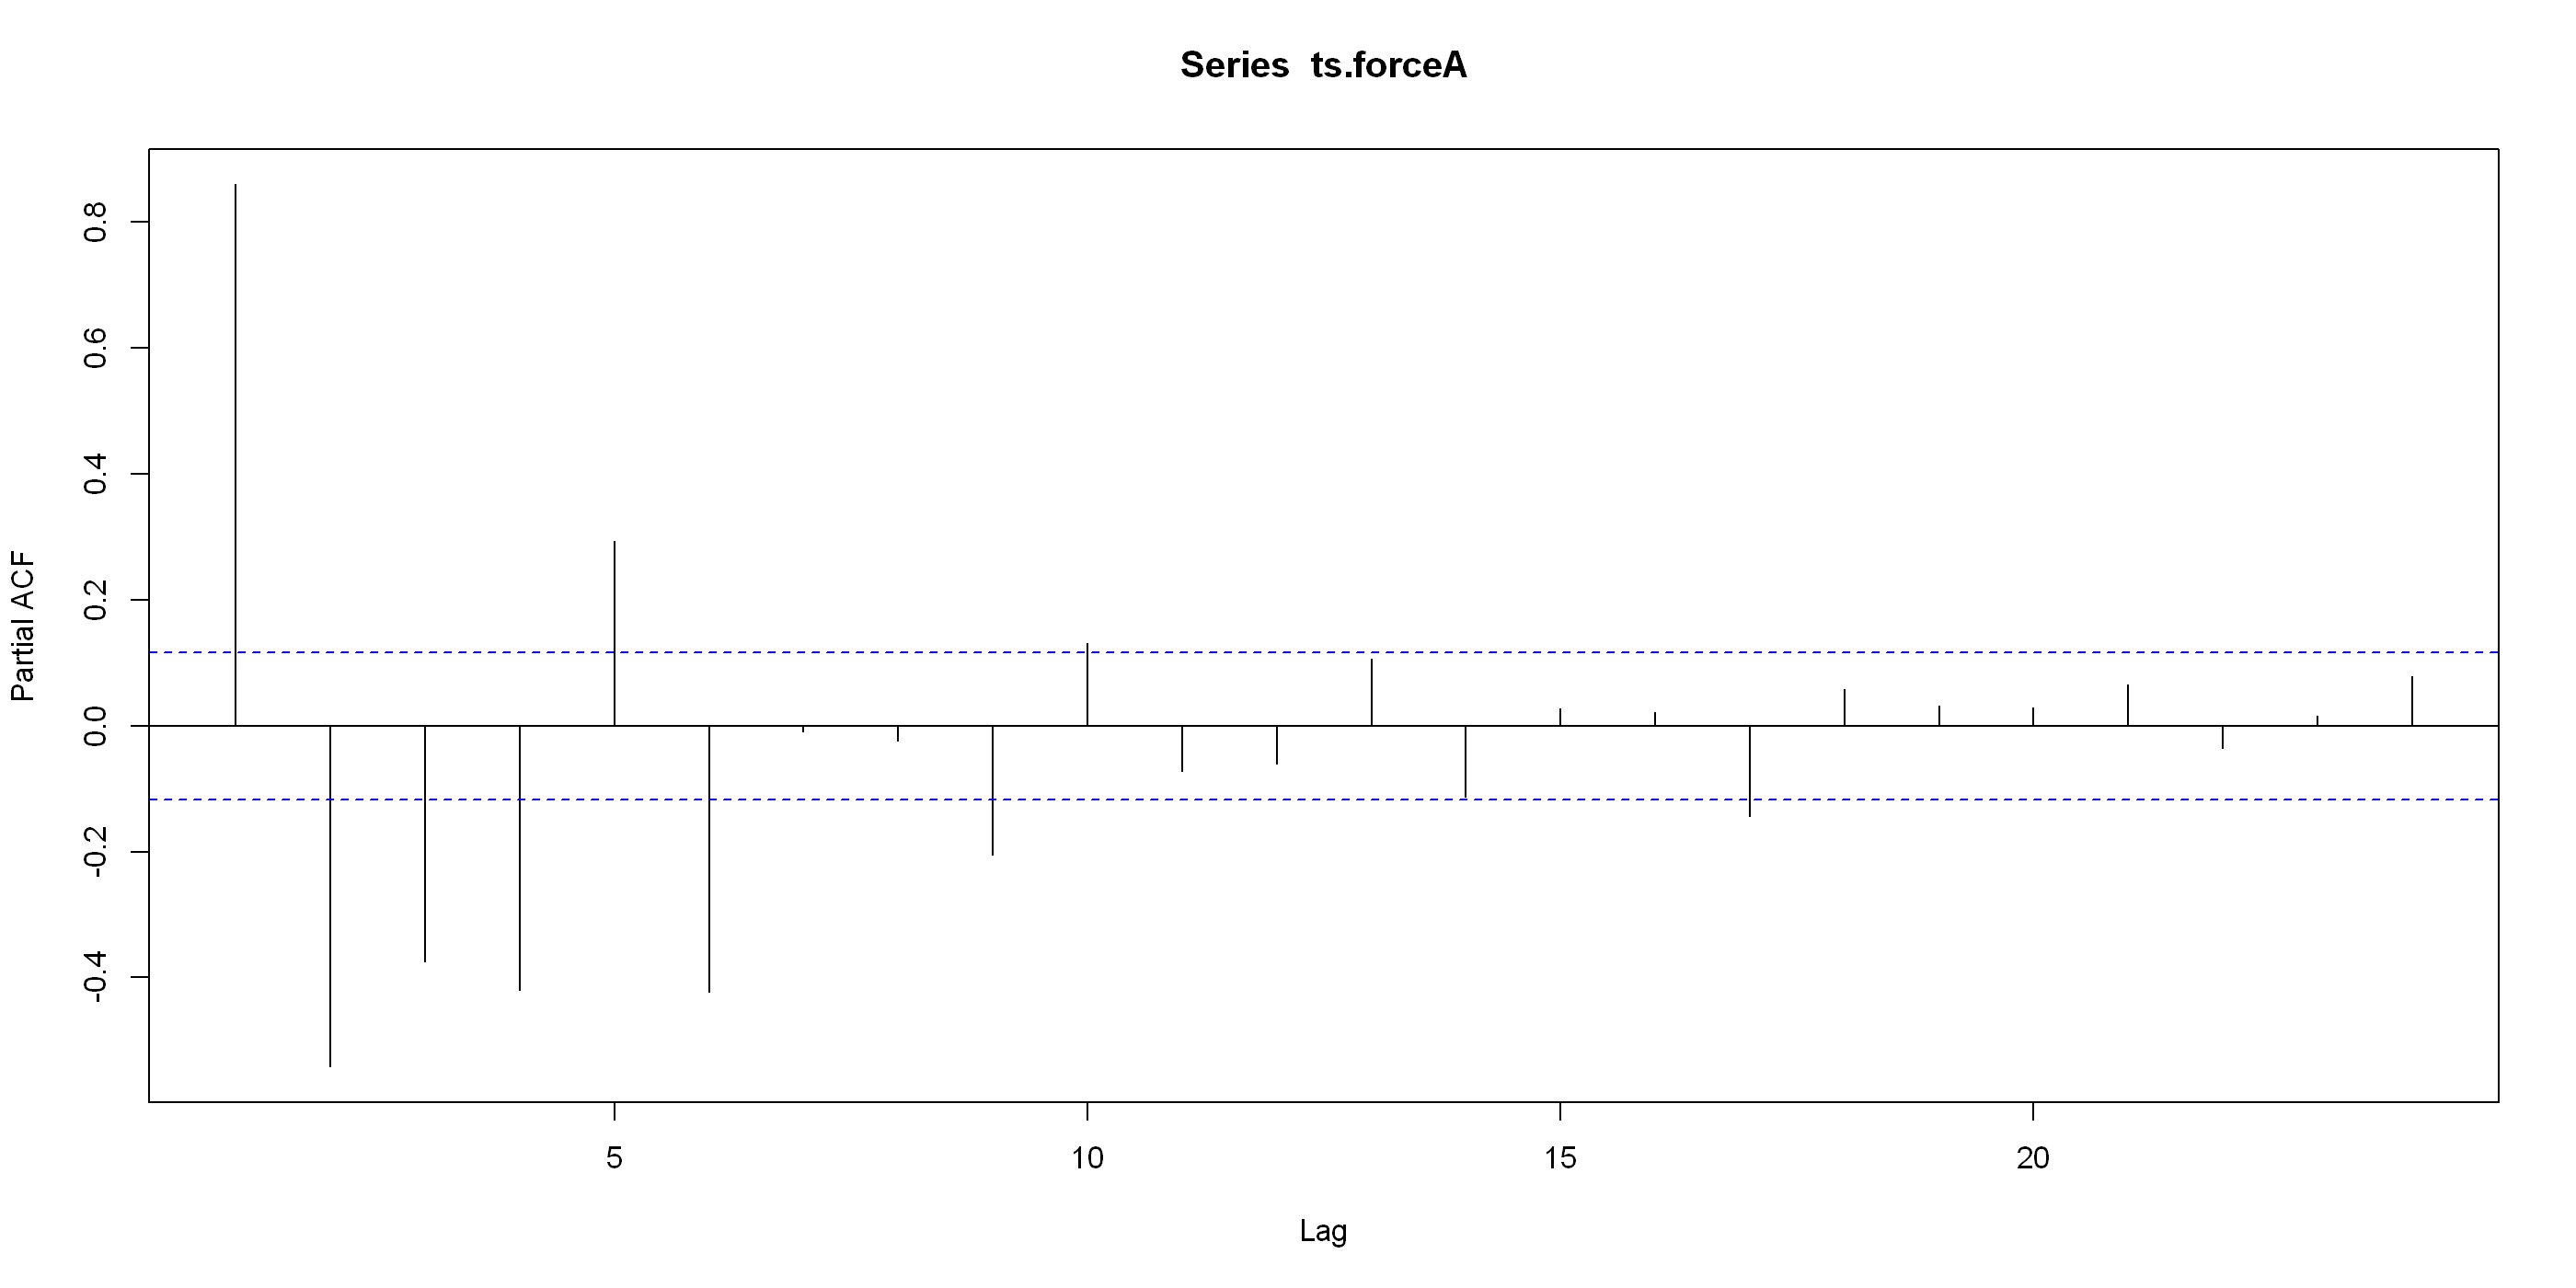

In [595]:
pacor <- pacf(ts.forceA)
print(pacor)

$$X_{t} = \sum^p_{k=1} \alpha_k X_{t-k}+\epsilon_t, \quad \text{with MLE } \epsilon_t \sim N(0,\sigma^2) $$

ACF:
$$\hat{\rho}(k) = \frac{\sum^{n-k}_{t=1}(X_{t-k}-\bar{X})(X_{t}-\bar{X})}{\sum^{n}_{t=1}(X_{t}-\bar{X})^2}$$
PACF:
$$\pi(k) = \rho(k|\sigma(\cup_{j\in \{1,...,k-1\}}X_{t-j}))$$

AR(P) with p = 6 seems reasonable, for the partial correlation is still relative up to and including that point. (one could even argue for p=10)

Warning message in xy.coords(x, y, xlabel, ylabel, log):
"1 y value <= 0 omitted from logarithmic plot"


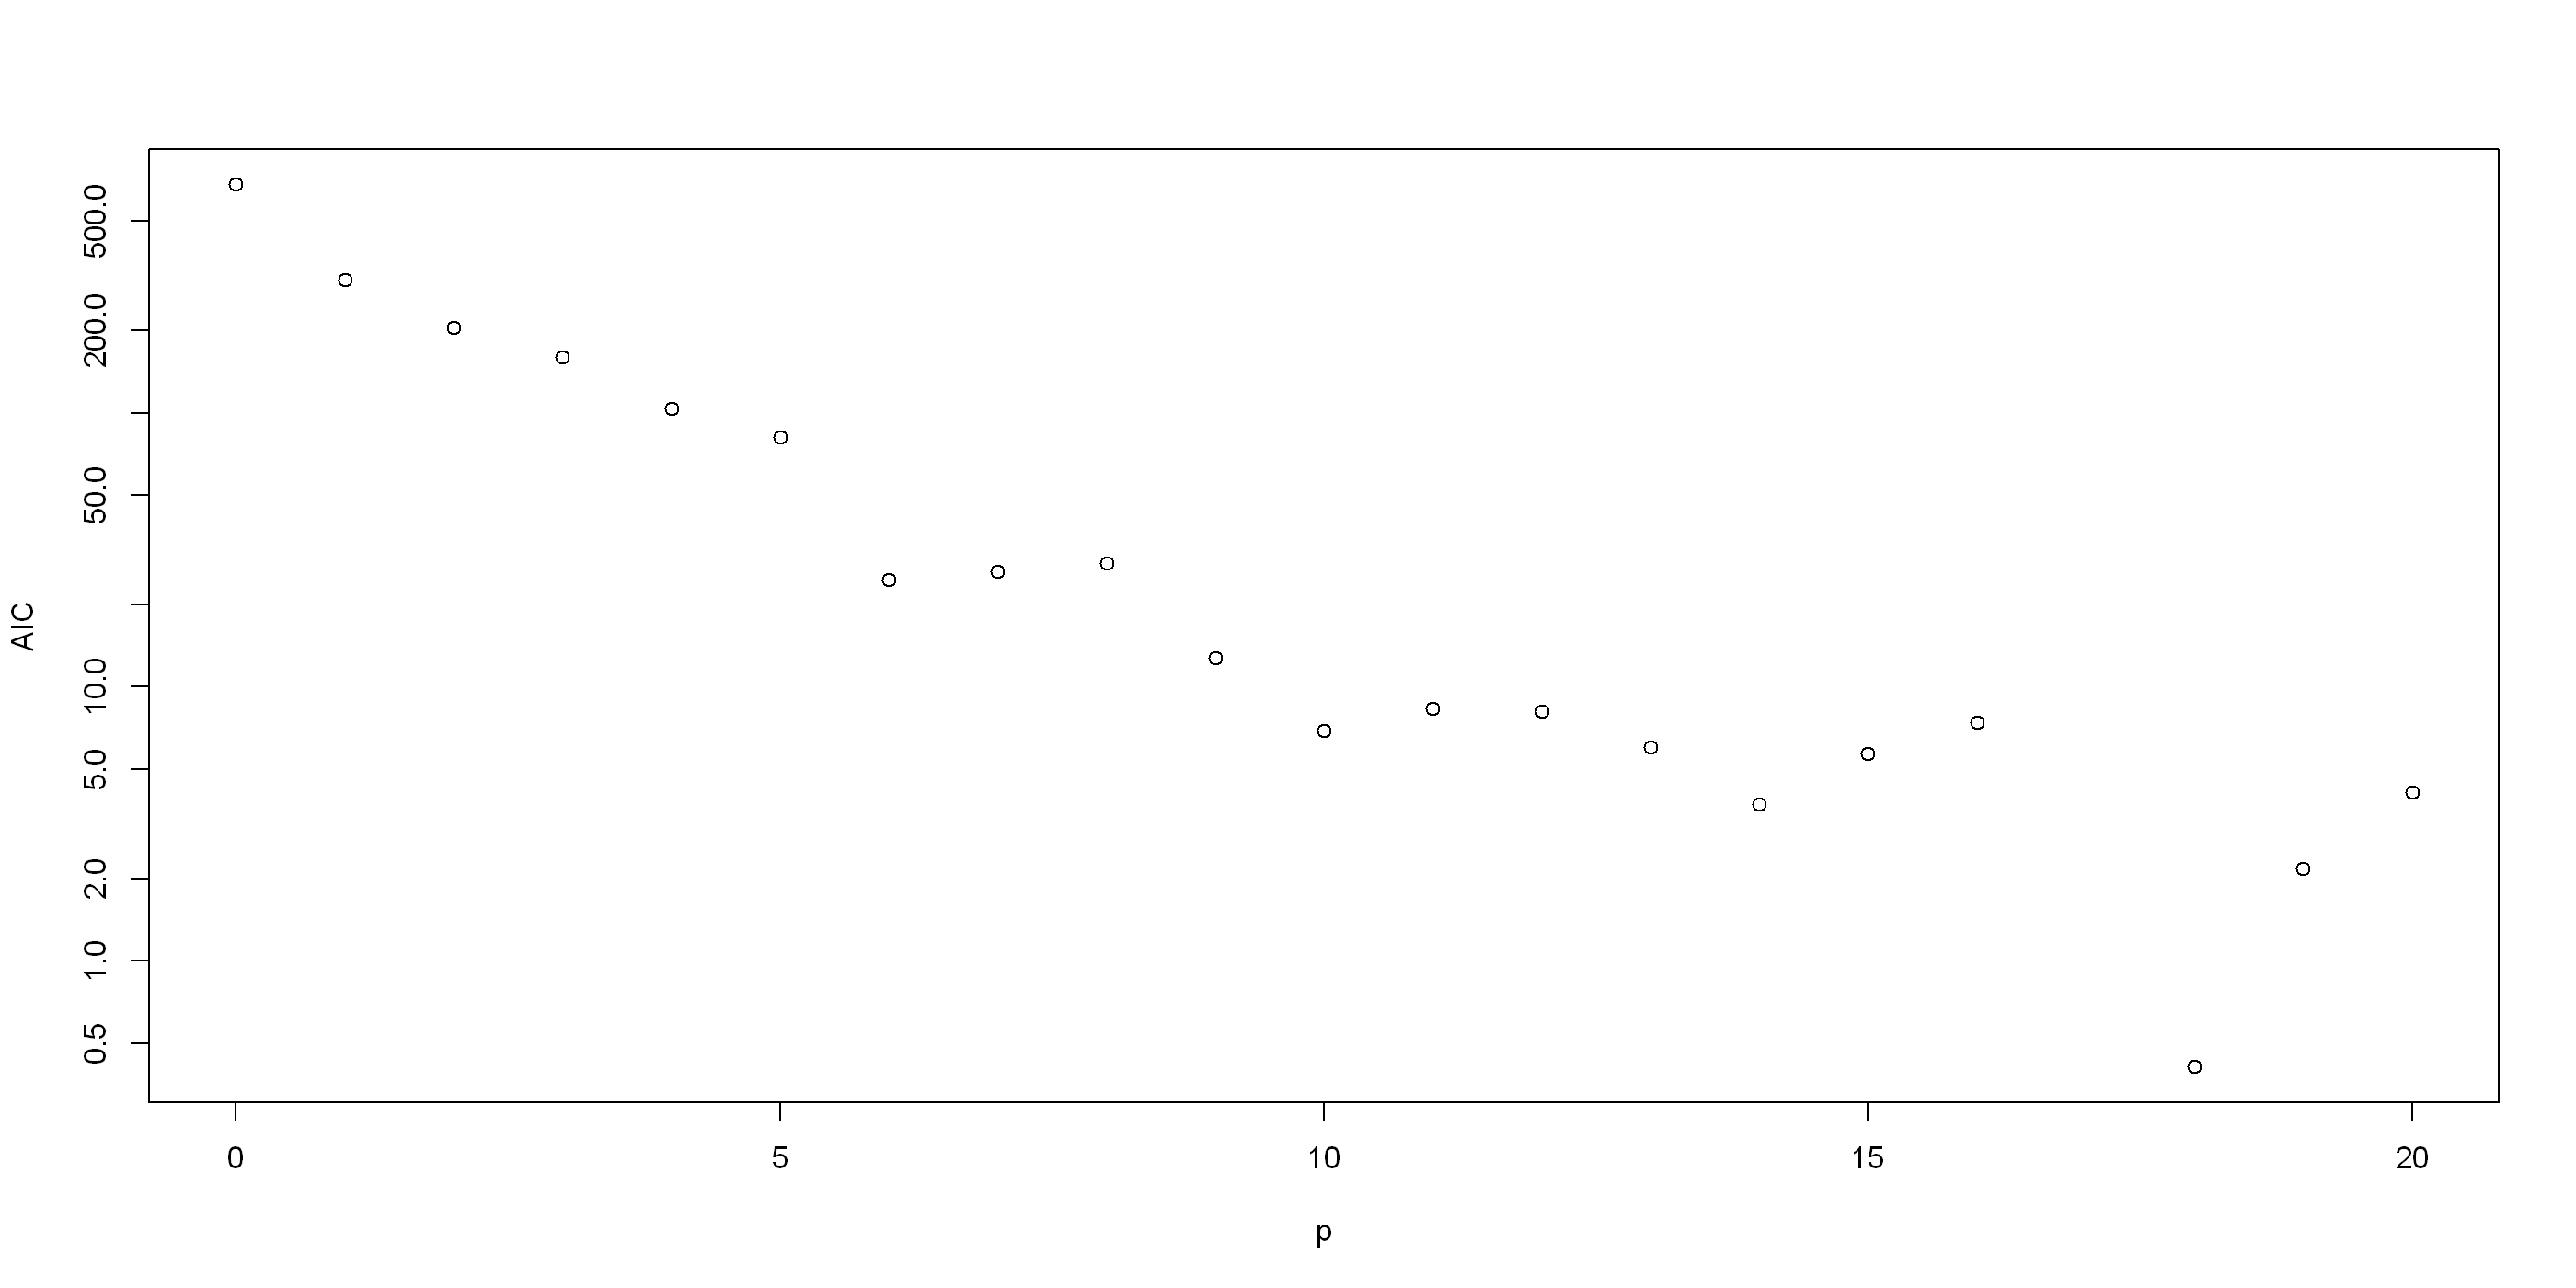

In [600]:
ar.forceA <- ar(ts.forceA,method = "mle",order.max = 20)
f <- function(x){return (x-1)}
ticks <-sapply(1:length(ar.forceA$aic),f)
plot(ticks,ar.forceA$aic,log="y",xlab = "p",ylab = "AIC")

Indeed consistent with the previous insights.

##### 3.3.c

In [ ]:
p_v <- c(6,10,17)
n = length(p_v)
ar.force_v <- vector(mode = "list",length = n)
ar.coef_cor <- vector(mode = "list",length = n)

for(p in 1:n)
{   
    ar.force_v[[p]] <-  arima(ts.forceA,order=c(p_v[p],0,0),method = "ML") # --> ARIMA(p,d,q) with d=q=0 <-> AR(p)
    ar.coef_cor[[p]] <- cor(ar.force_v[[p]]$coef,pacor$acf[1:(p_v[p]+1)])

}

str(ar.force_v[[1]])
str(ar.coef_cor)
print(unlist(ar.coef_cor))

List of 14
 $ coef     : Named num [1:7] 1.205 -0.387 0.166 -0.746 0.772 ...
  ..- attr(*, "names")= chr [1:7] "ar1" "ar2" "ar3" "ar4" ...
 $ sigma2   : num 0.0091
 $ var.coef : num [1:7, 1:7] 0.002898 -0.003141 0.000247 -0.00041 0.00214 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:7] "ar1" "ar2" "ar3" "ar4" ...
  .. ..$ : chr [1:7] "ar1" "ar2" "ar3" "ar4" ...
 $ mask     : logi [1:7] TRUE TRUE TRUE TRUE TRUE TRUE ...
 $ loglik   : num 258
 $ aic      : num -500
 $ arma     : int [1:7] 6 0 0 0 1 0 0
 $ residuals: Time-Series [1:280] from 1 to 280: -0.0287 0.1621 -0.04 -0.0168 -0.0178 ...
 $ call     : language arima(x = ts.forceA, order = c(p_v[p], 0, 0), method = "ML")
 $ series   : chr "ts.forceA"
 $ code     : int 0
 $ n.cond   : num 0
 $ nobs     : int 280
 $ model    :List of 10
  ..$ phi  : num [1:6] 1.205 -0.387 0.166 -0.746 0.772 ...
  ..$ theta: num [1:5] 0 0 0 0 0
  ..$ Delta: num(0) 
  ..$ Z    : num [1:6] 1 0 0 0 0 0
  ..$ a    : num [1:6] -0.344 0.106 -0.208 0

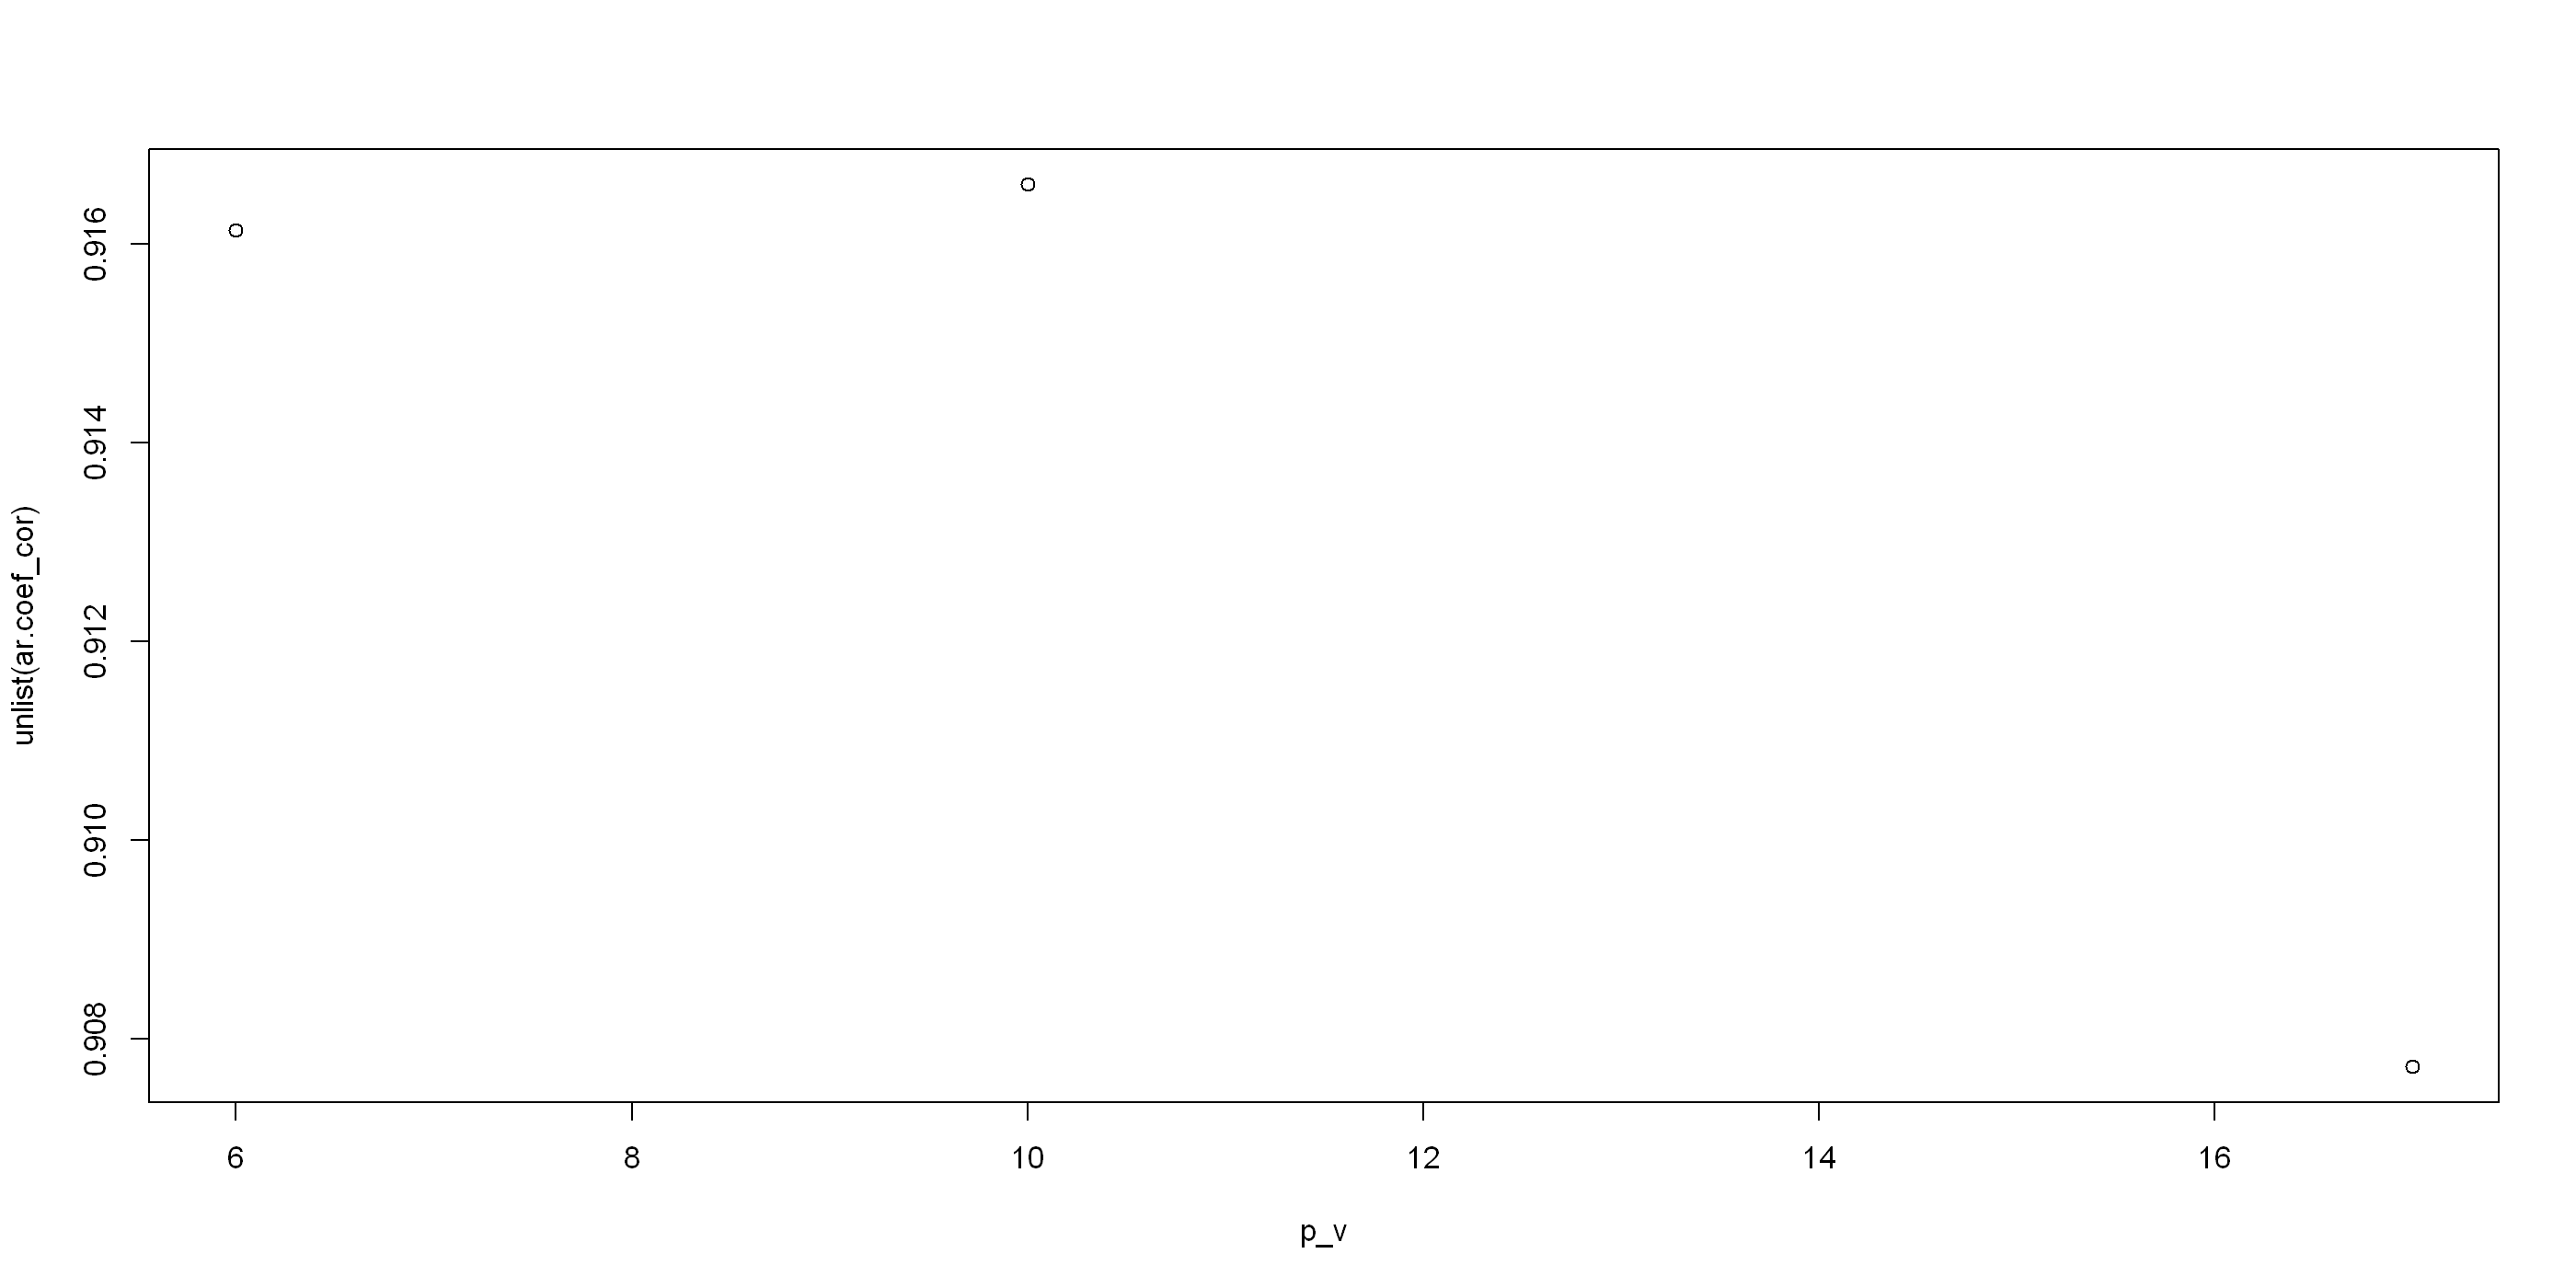

In [637]:
plot(p_v,unlist(ar.coef_cor))

##### 3.3.d

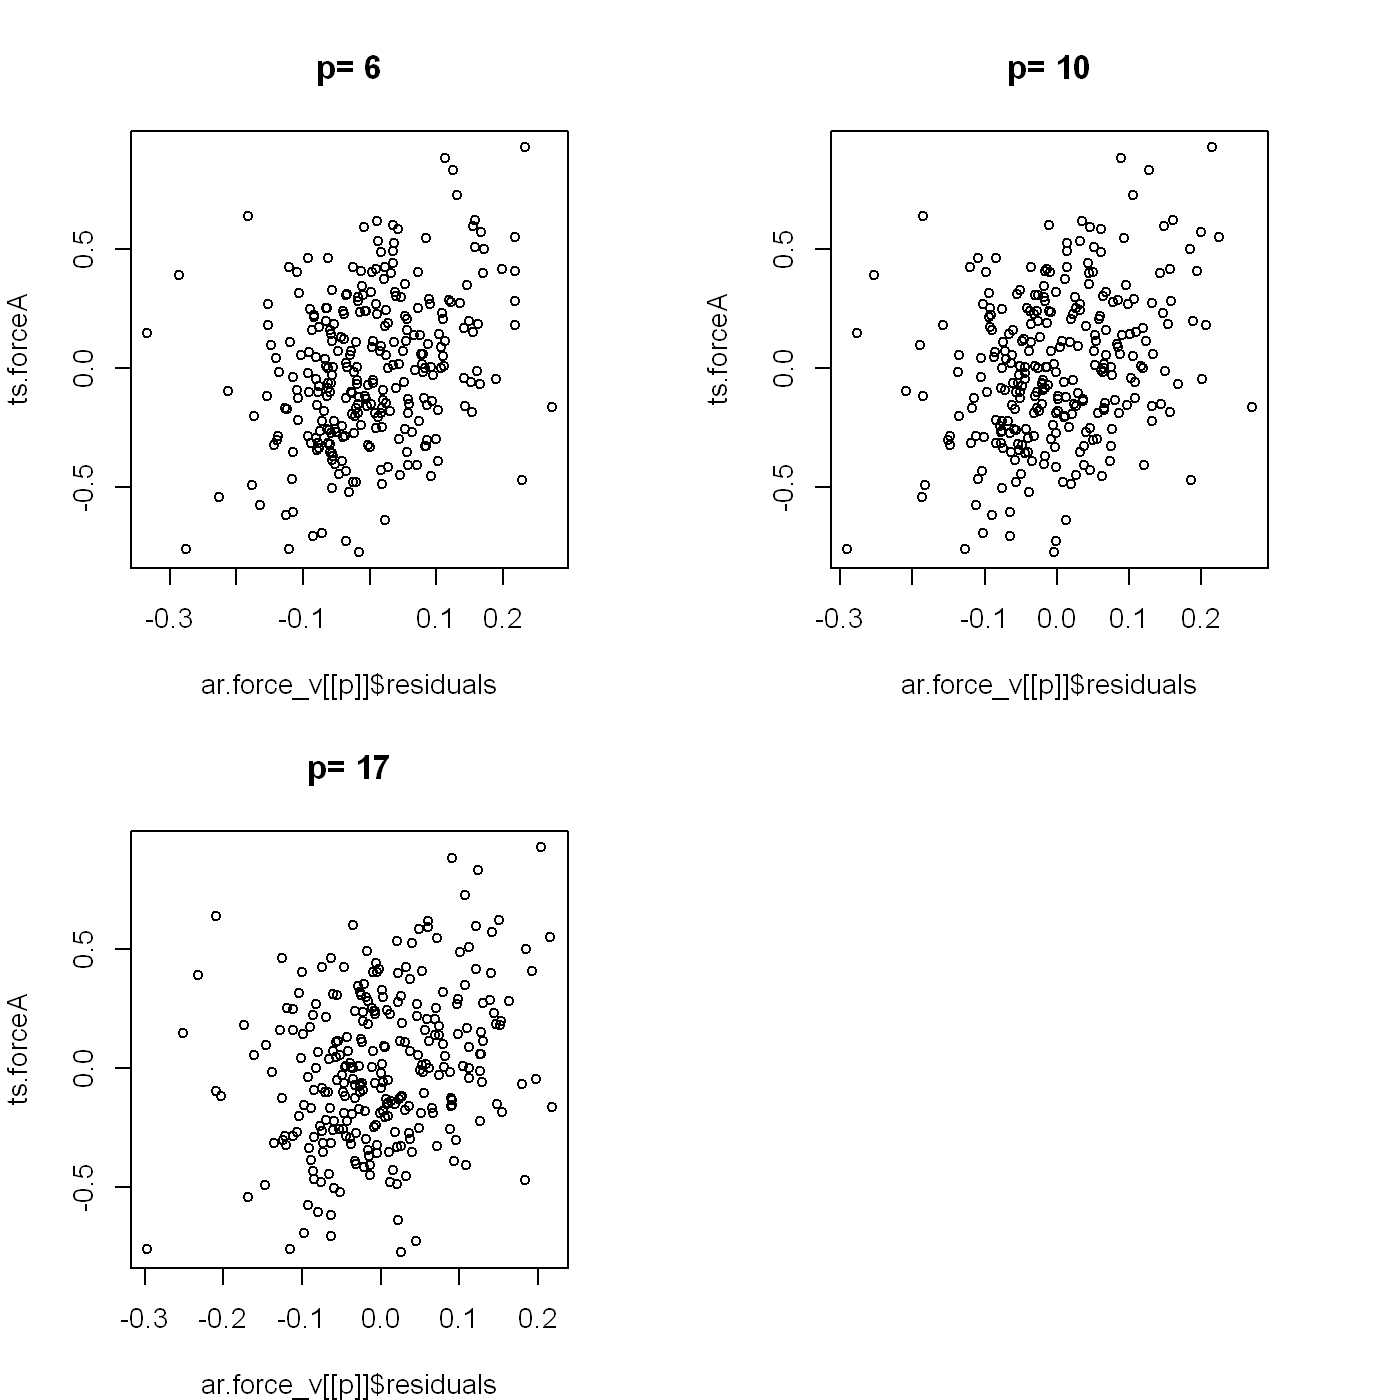

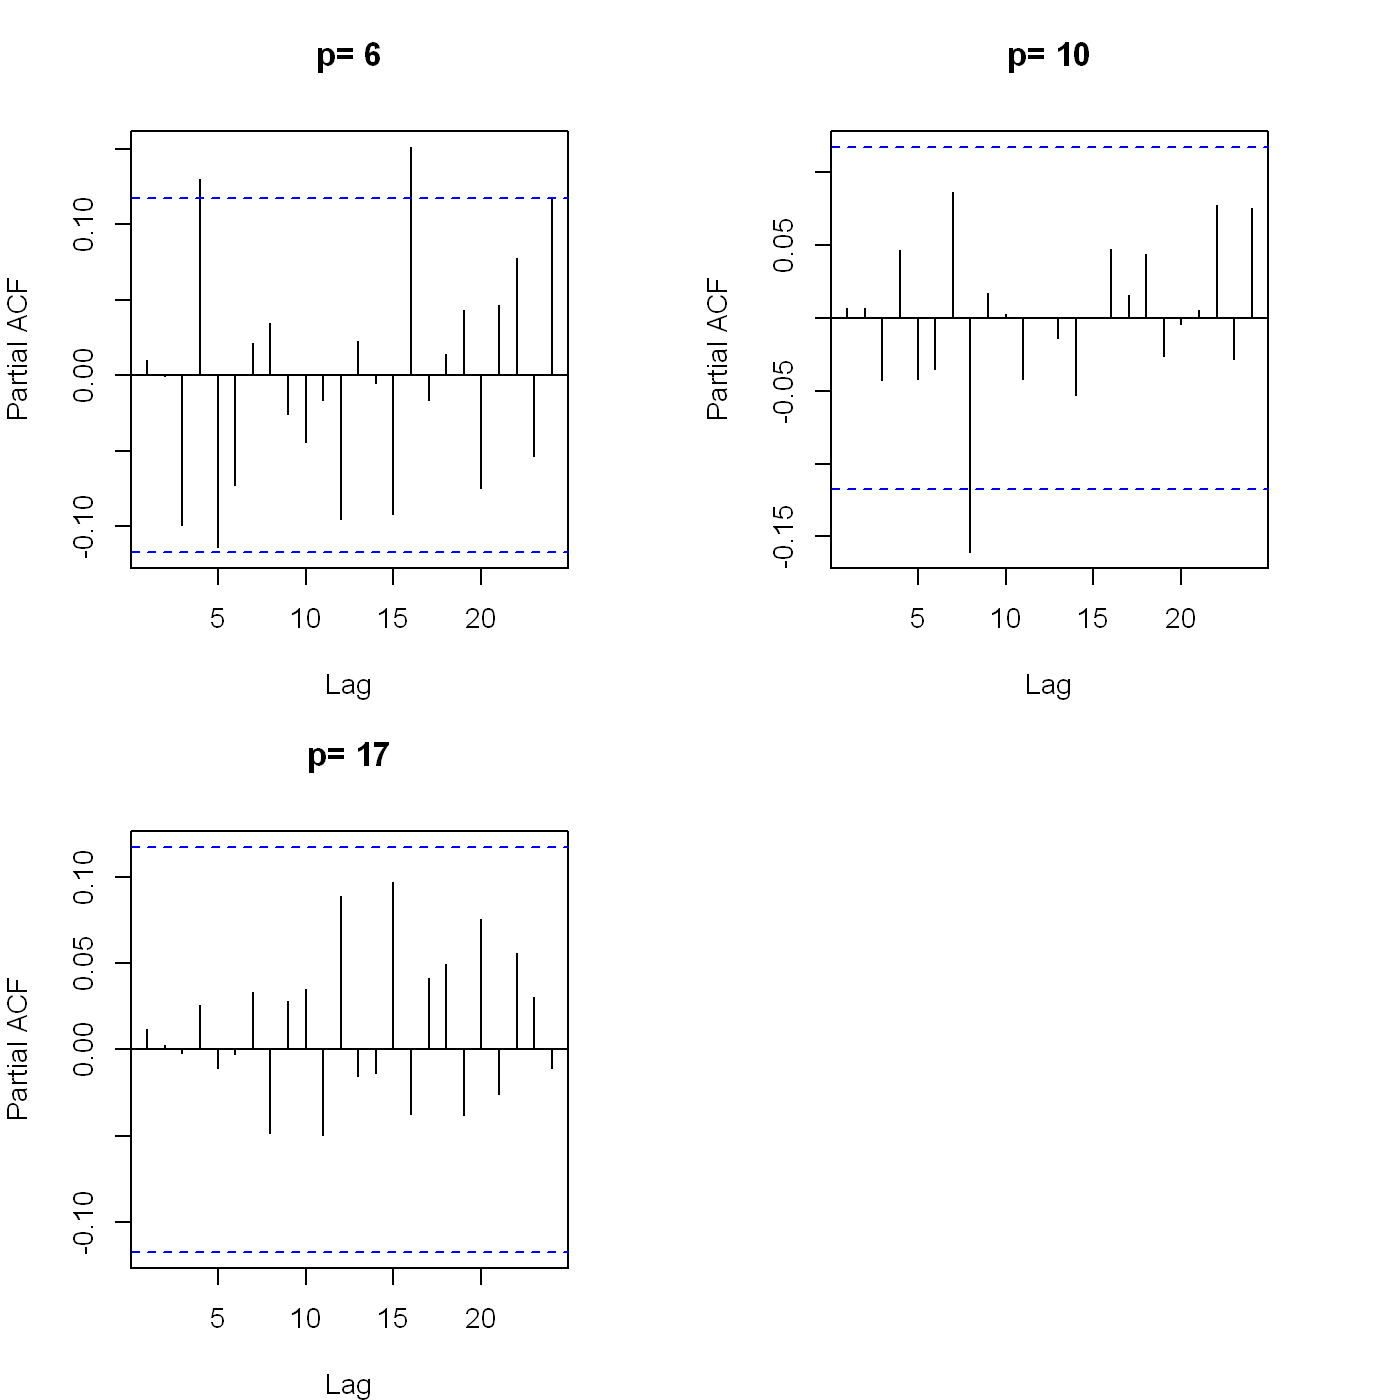

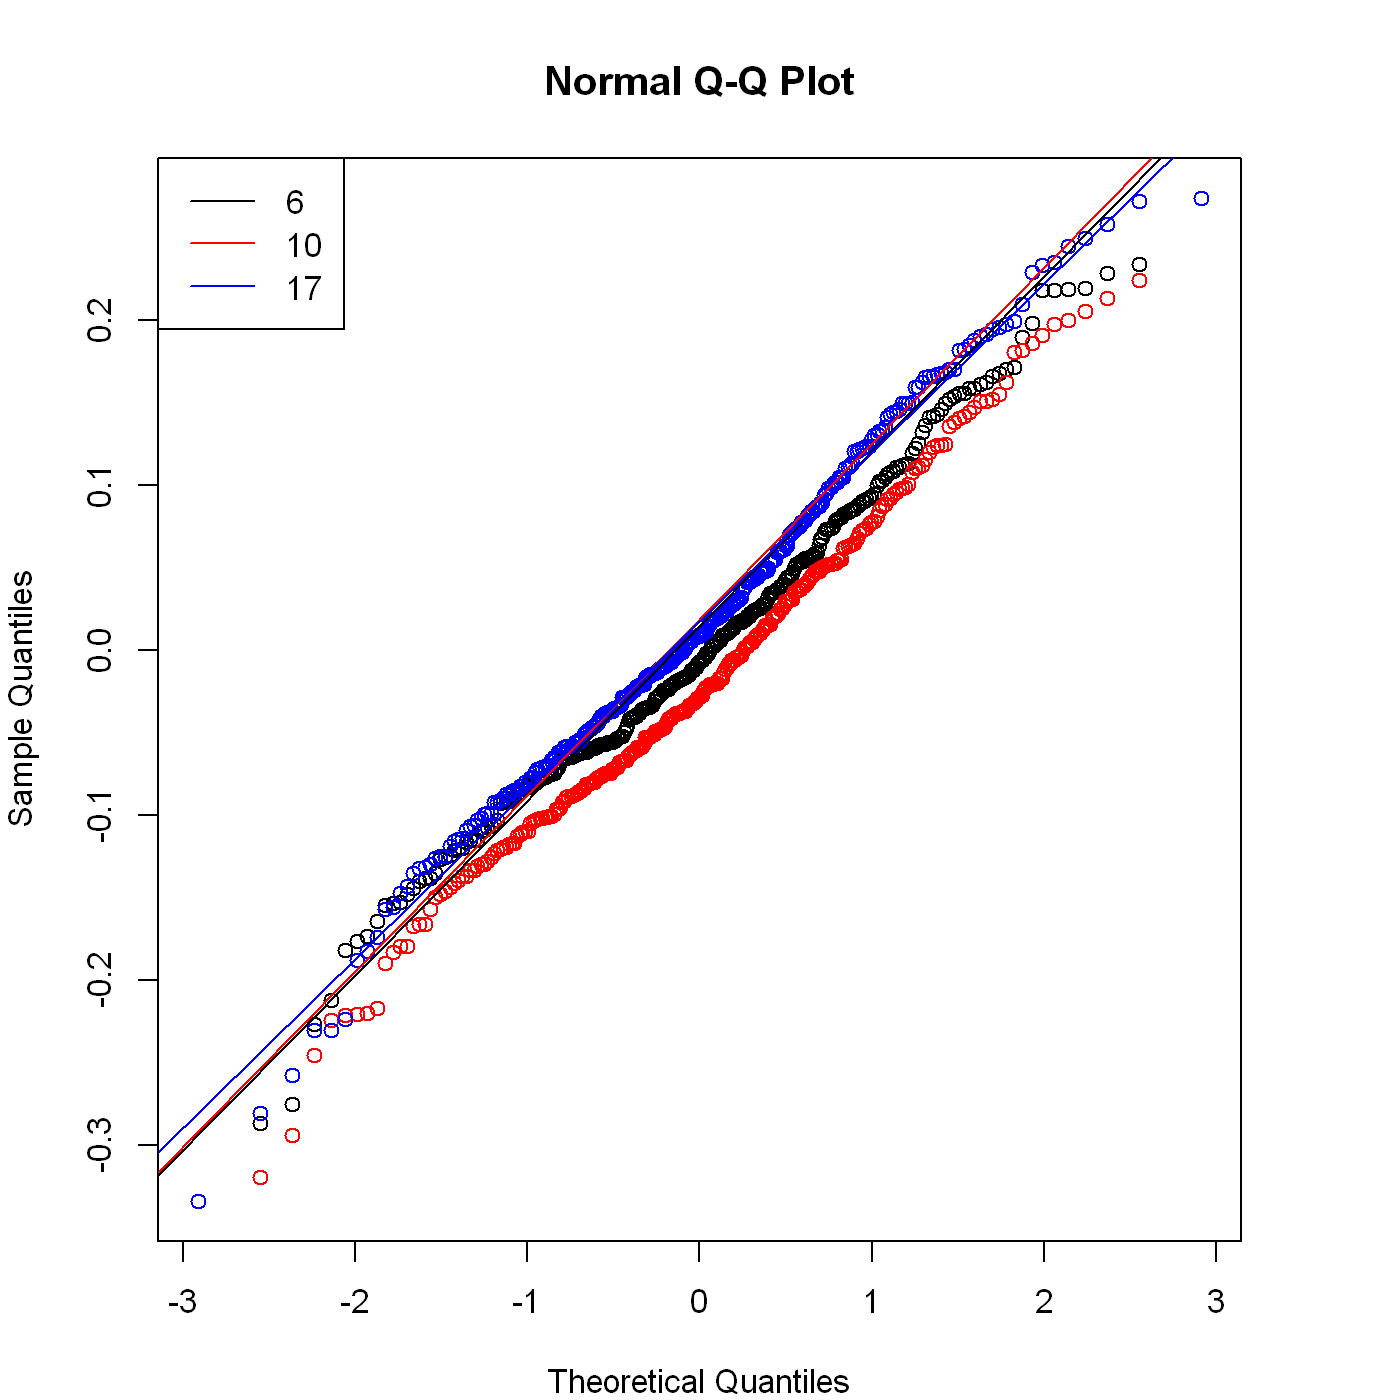

In [639]:
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 200)

par(mfrow = c(round(n/2),2),mar=c(4,4,4,4))
for(p in 1:n)
{   
    plot(ar.force_v[[p]]$residuals,ts.forceA,main=paste("p=",p_v[p]))
    
}

par(mfrow = c(round(n/2),2),mar=c(4,4,4,4))

for(p in 1:n)
{   
    pacf(ar.force_v[[p]]$residuals,main=paste("p=",p_v[p]))
    
}




par(mfrow = c(1,1),mar=c(4,4,4,4))
qqnorm(ar.force_v[[1]]$residuals)
par(new = TRUE)
qqnorm(ar.force_v[[2]]$residuals,col="red",axes = FALSE, xlab = "", ylab = "", main = "")
par(new = TRUE)
qqnorm(ar.force_v[[3]]$residuals,col="blue",axes = FALSE, xlab = "", ylab = "", main = "")
qqline(ar.force_v[[1]]$residuals)
qqline(ar.force_v[[2]]$residuals,col="red")
qqline(ar.force_v[[3]]$residuals,col="blue")

legend("topleft", legend =p_v, col = c("black","red","blue"), lty = 1)

options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)



As can be seen this indeed seems to be a rather good fit (for the choice of p = 6,10,17, notably each is fine, probably one should chose 6 or 10, to reduce complexity and there might be a reason to argue in both ways for 6, namely due to correct bounds of the PACF plot)

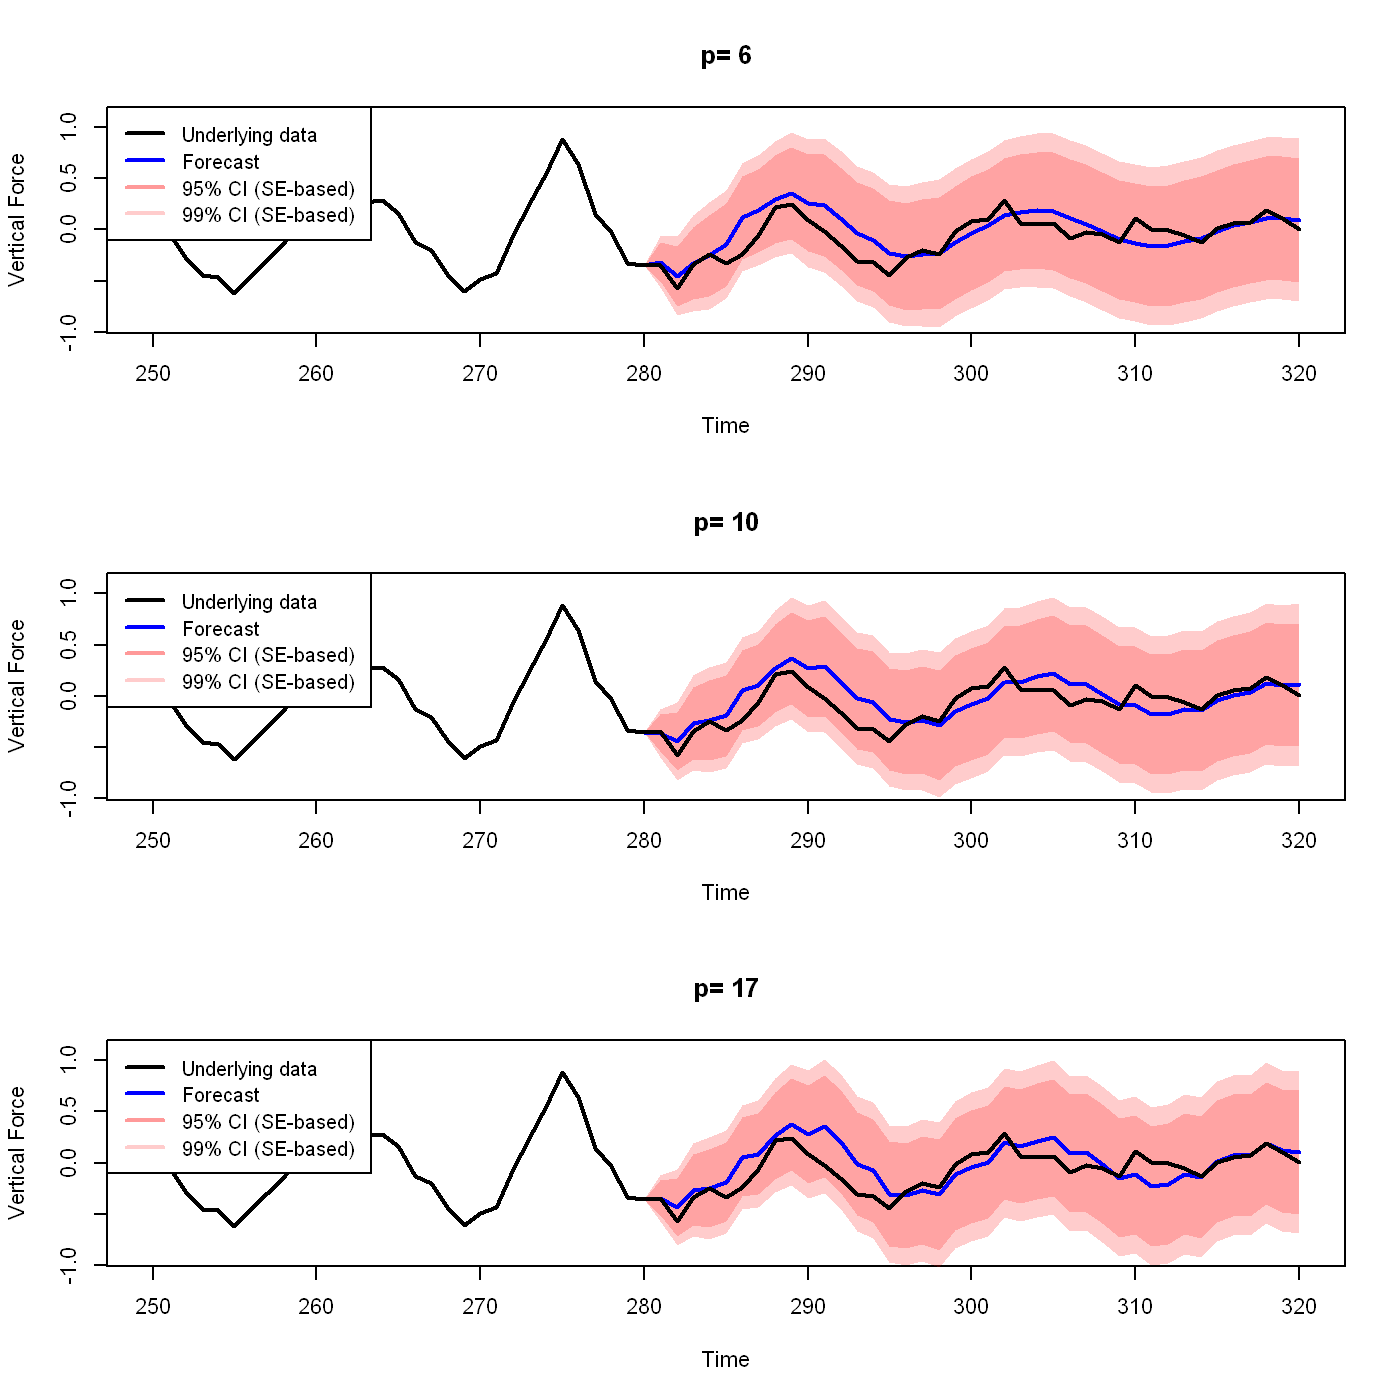

In [653]:
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 200)

ar.preds<- vector(mode = "list",length = 2)

alpha95=0.05
alpha99=0.01
z95 = qnorm(1-alpha95/2)
z99 = qnorm(1-alpha99/2)
n_x = length(ts.forceA)
# col = rainbow(length(p_v),s = 1, v = 1)
par(mfrow = c(3,1))
for(p in 1:n)
{
    force.pred <- predict(ar.force_v[[p]],n.ahead = 40)
    x_pred <- time(force.pred$pred)
    x_conn <- c(time(ts.forceA)[n_x], x_pred)
    y_conn <- c((ts.forceA)[n_x], force.pred$pred)
    se_conn <- c(0,force.pred$se)



    plot(window(ts.force,start = 250),lw=2,ylim = c(1.2*min(ts.force),1.2*max(ts.force)),ylab="Vertical Force",main=paste("p=",p_v[p]))
    polygon(c(x_conn,rev(x_conn)),c(y_conn+ z99 * se_conn, rev(y_conn - z99 * se_conn)),col=adjustcolor("red",alpha.f = 0.2),border = NA)
    polygon(c(x_conn,rev(x_conn)),c(y_conn+ z95 * se_conn, rev(y_conn - z95 * se_conn)),col=adjustcolor("red",alpha.f = 0.2),border = NA)
    lines(x_conn,y_conn,col = "blue",lw=2)
    lines(window(ts.force,start = 250),lw=2,ylim = c(1.2*min(ts.force),1.2*max(ts.force)),ylab="Vertical Force")

    legend("topleft",cex=0.9,legend = c("Underlying data","Forecast","95% CI (SE-based)","99% CI (SE-based)"),col=c("black","blue",col=adjustcolor("red",alpha.f = 0.4),col=adjustcolor("red",alpha.f = 0.2)),lty = c(1,1,1,1),lw=c(2,2,2))
}

options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


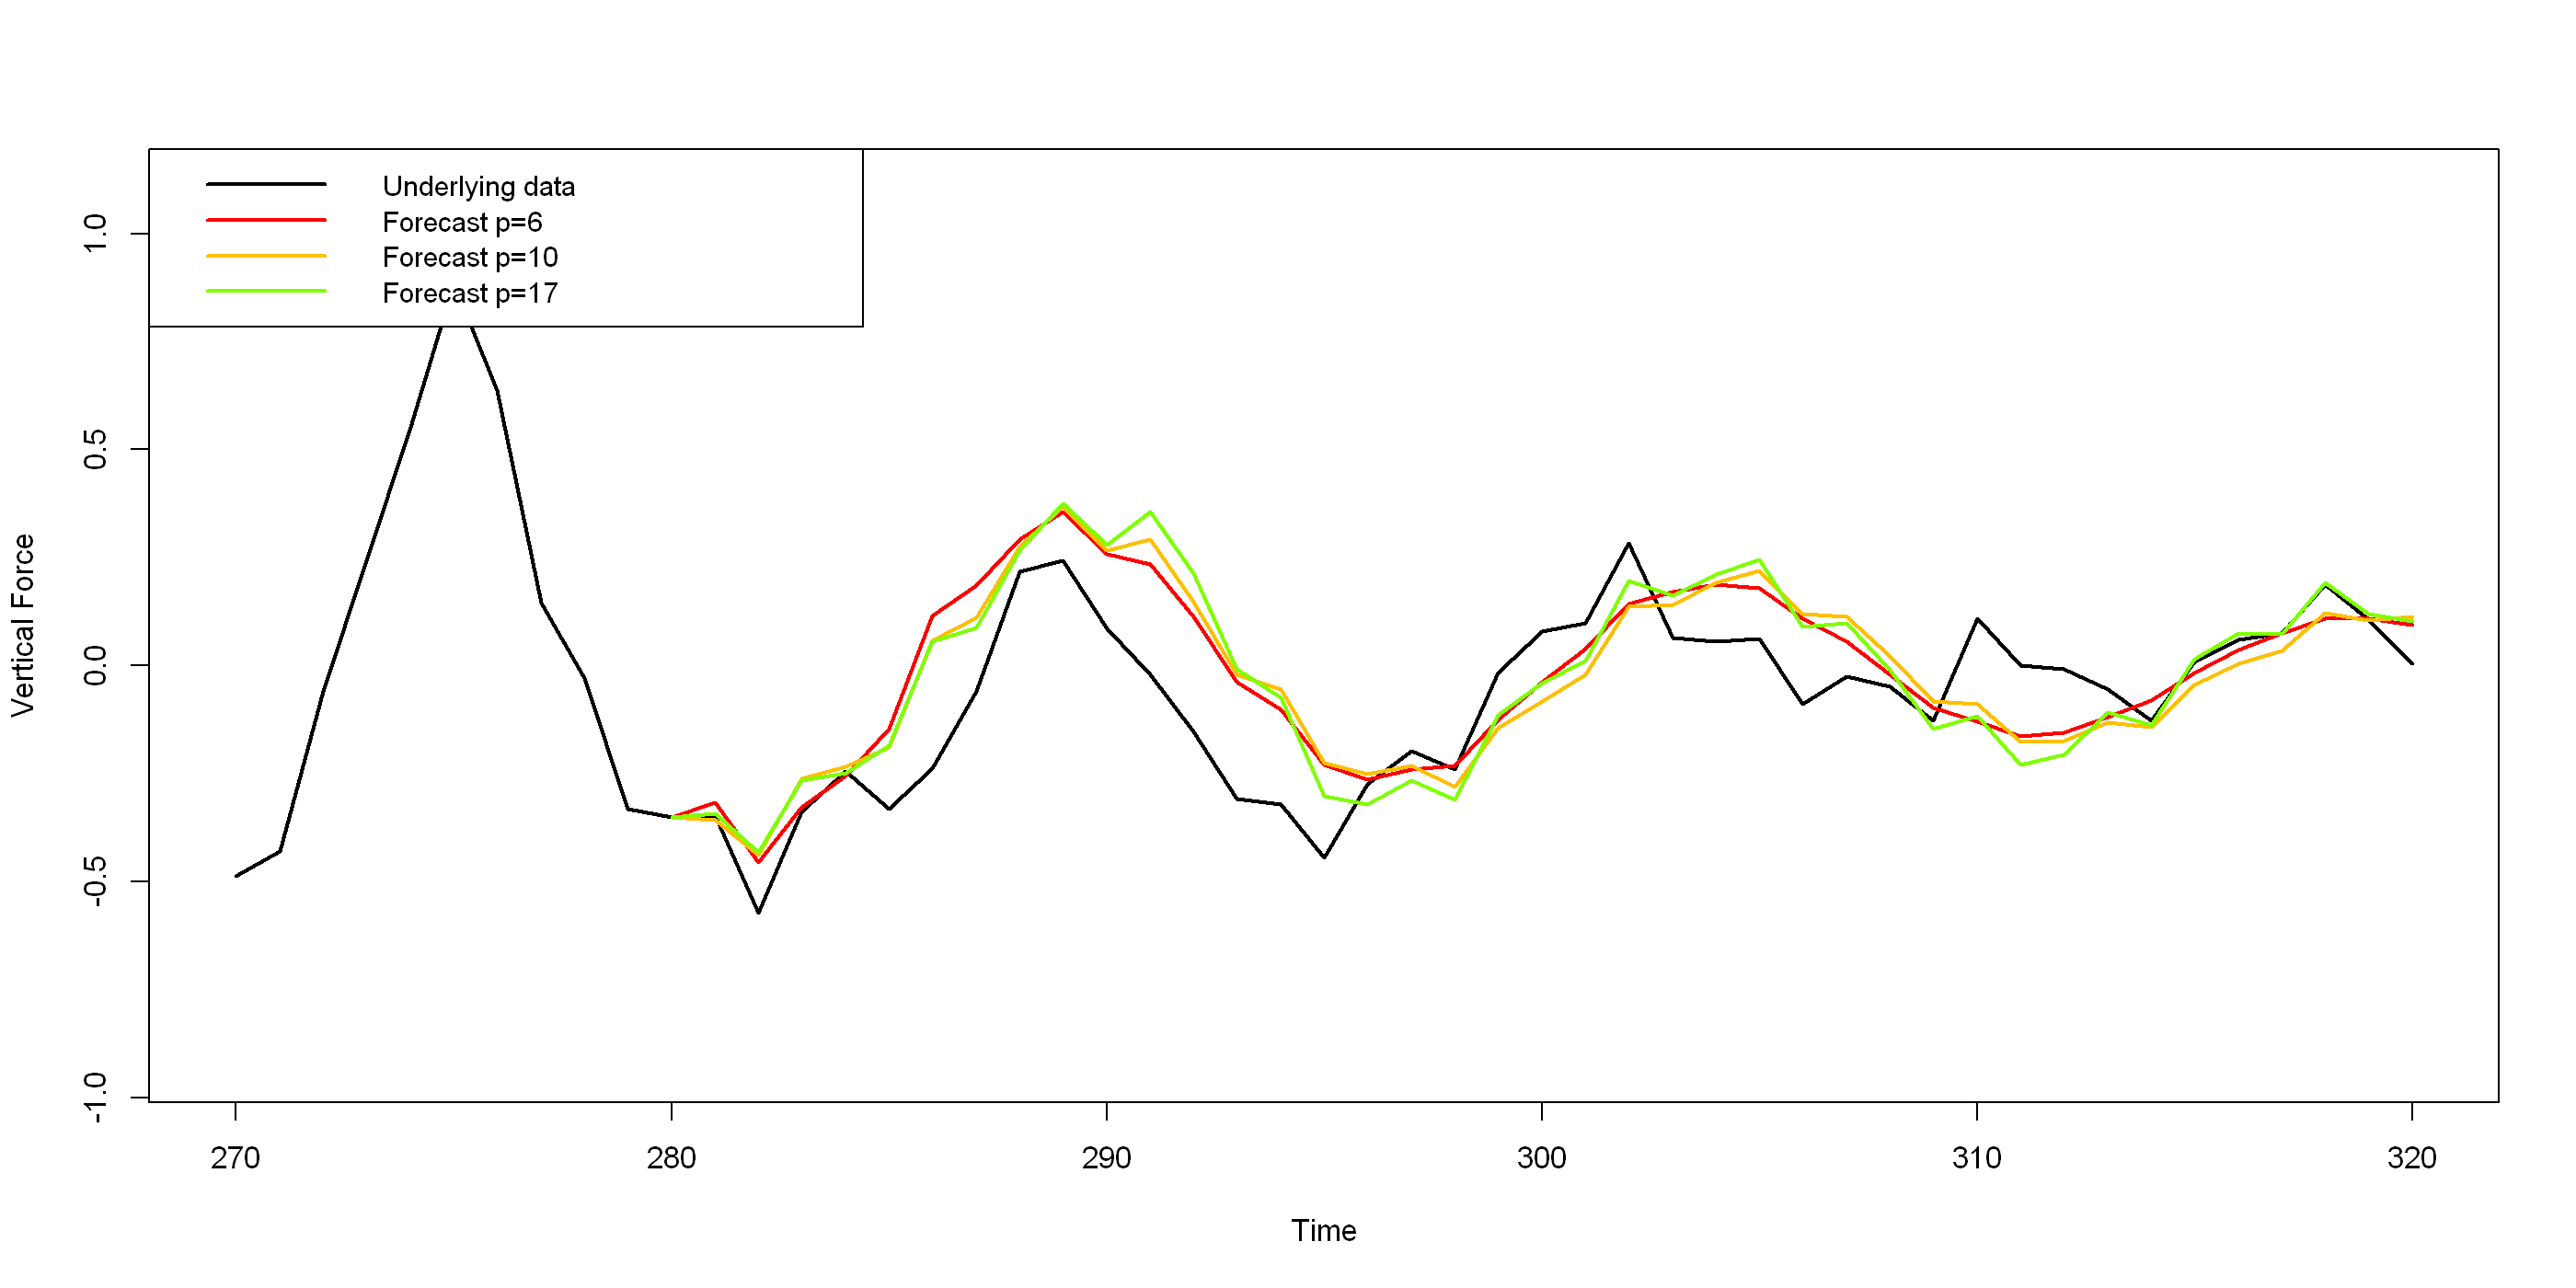

In [671]:
plot(window(ts.force,start = 270),lw=2,ylim = c(1.2*min(ts.force),1.2*max(ts.force)),ylab="Vertical Force")

for(p in 1:n)
{
    force.pred <- predict(ar.force_v[[p]],n.ahead = 40)
    x_pred <- time(force.pred$pred)
    x_conn <- c(time(ts.forceA)[n_x], x_pred)
    y_conn <- c((ts.forceA)[n_x], force.pred$pred)
    se_conn <- c(0,force.pred$se)
    # polygon(c(x_conn,rev(x_conn)),c(y_conn+ z99 * se_conn, rev(y_conn - z99 * se_conn)),col=adjustcolor("red",alpha.f = 0.2),border = NA)
    # polygon(c(x_conn,rev(x_conn)),c(y_conn+ z95 * se_conn, rev(y_conn - z95 * se_conn)),col=adjustcolor("red",alpha.f = 0.2),border = NA)
    lines(x_conn,y_conn,col = col[p],lw=2)
    # lines(window(ts.force,start = 250),lw=2,ylim = c(1.2*min(ts.force),1.2*max(ts.force)),ylab="Vertical Force")

}
legend("topleft",cex=0.9,legend = c("Underlying data","Forecast p=6","Forecast p=10","Forecast p=17"),col=c("black",col),lty = c(1,1,1,1),lw=c(2,2,2))


### 3.4

![ex3_4.png](ex3_4.png)

In [483]:
d.yields <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/yields.dat",header = FALSE)
t.yields <- ts(d.yields[, 1])

##### 3.4.a

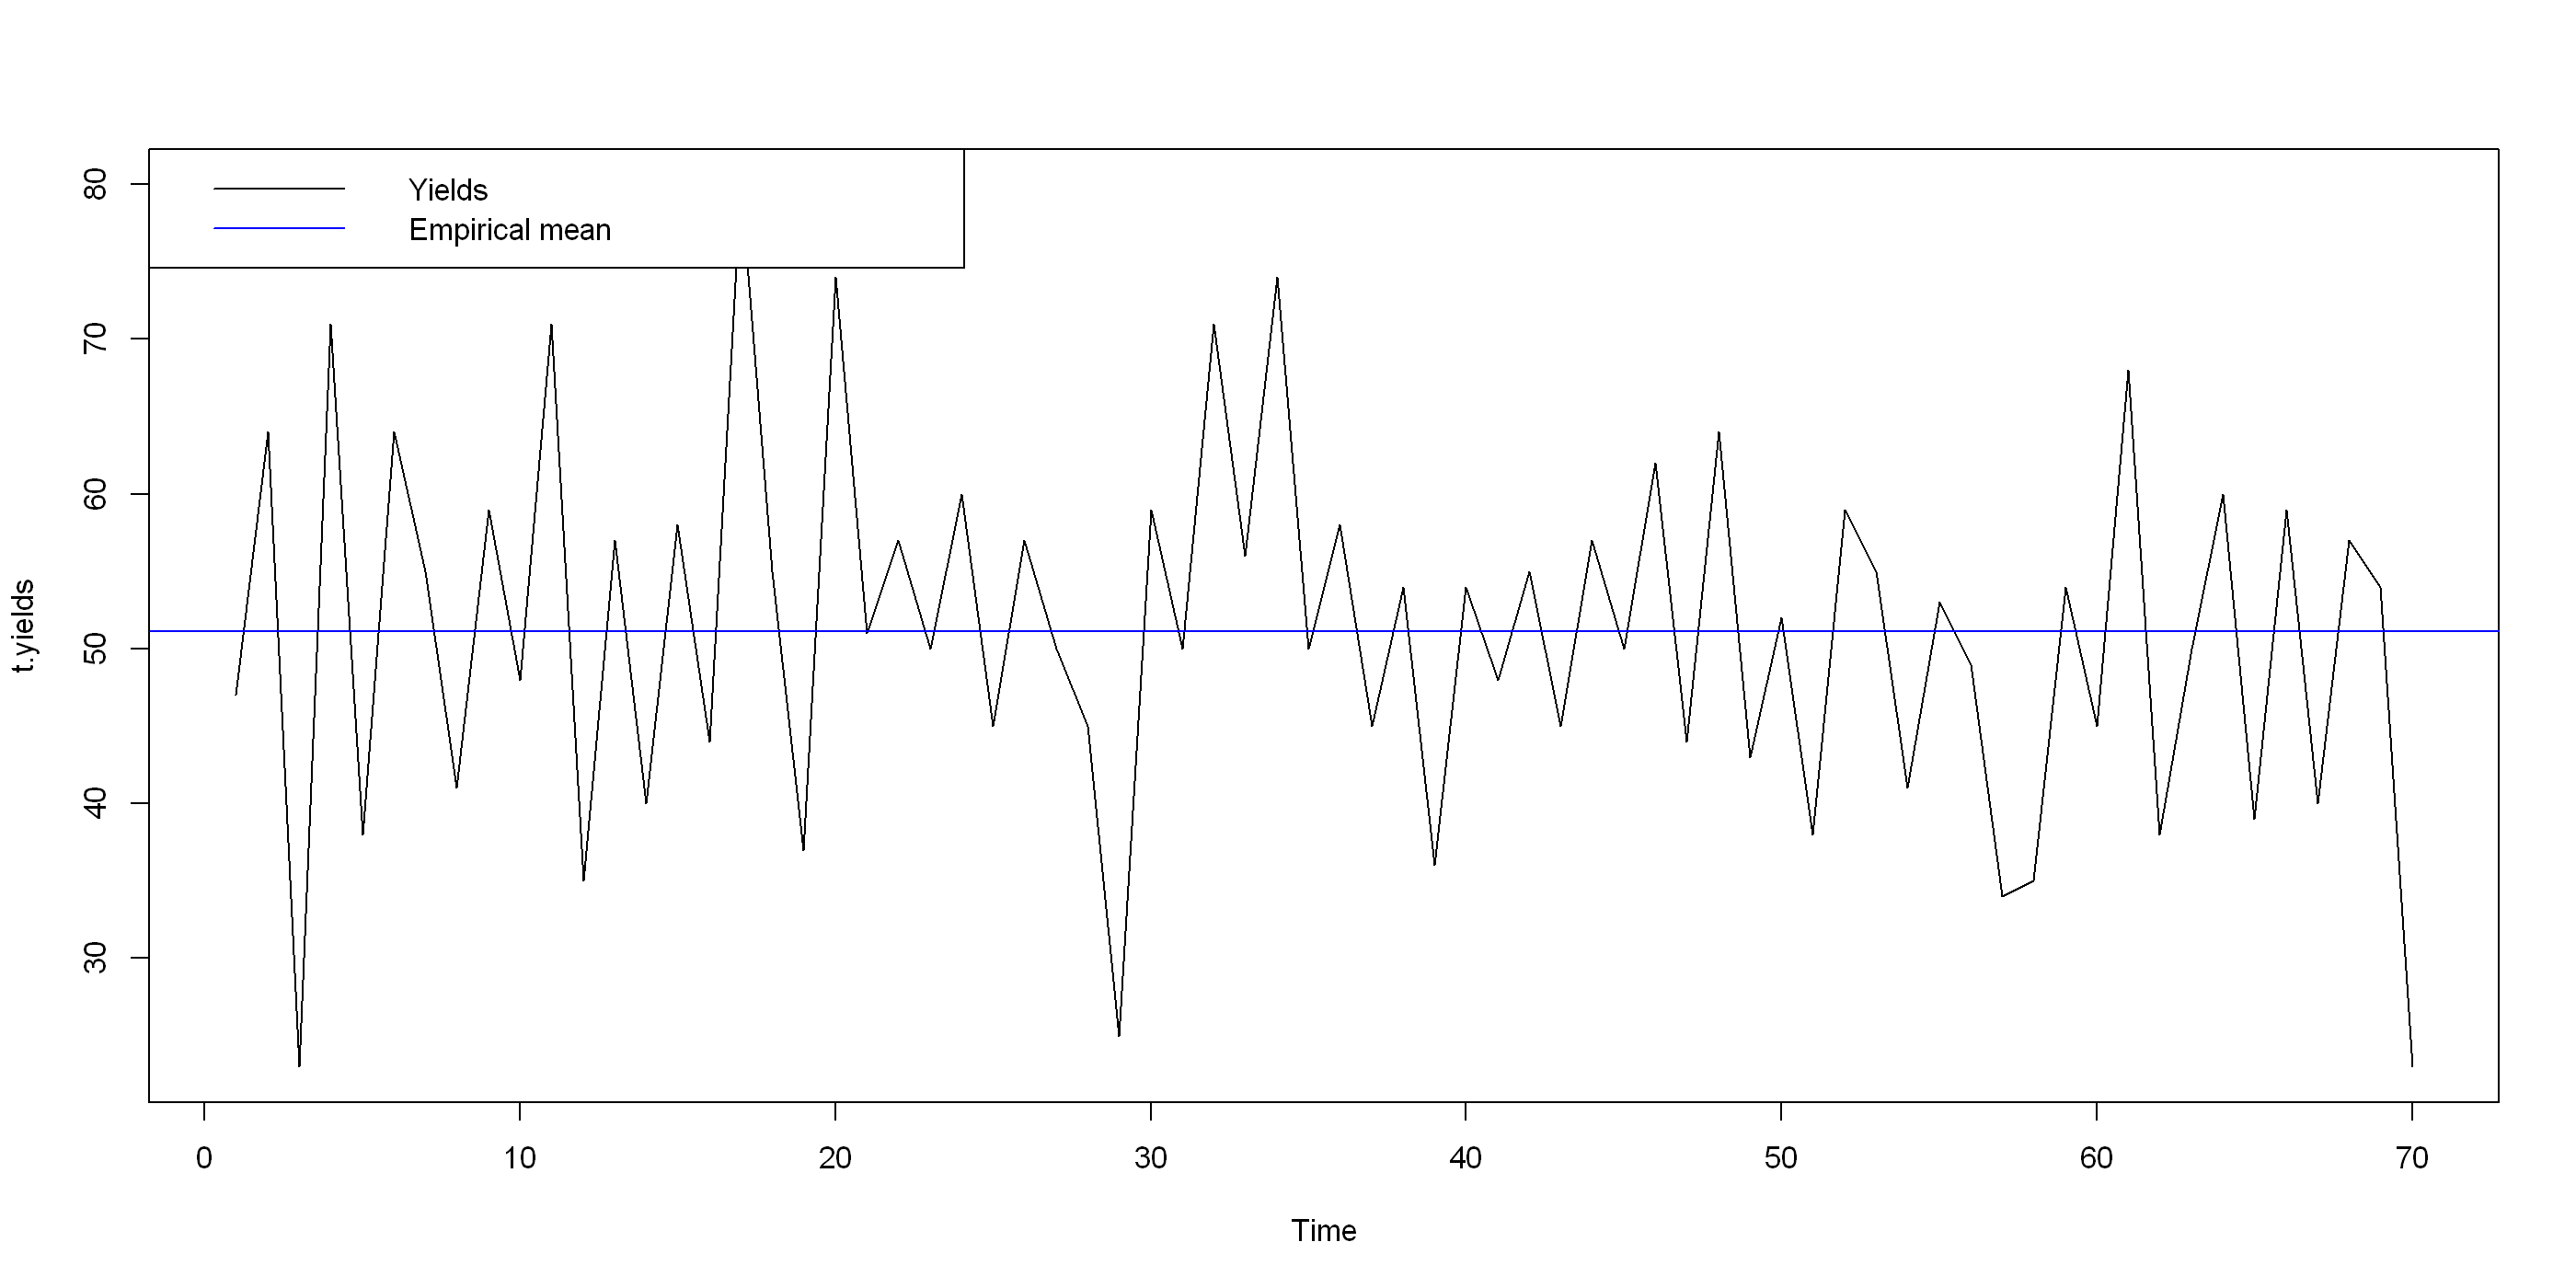

In [490]:
plot(t.yields)
mu_hat = mean(t.yields)
abline(h=mu_hat,col="blue")
legend("topleft",legend = c("Yields","Empirical mean"), col=c("black","blue"),lwd=1)

##### 3.4.b

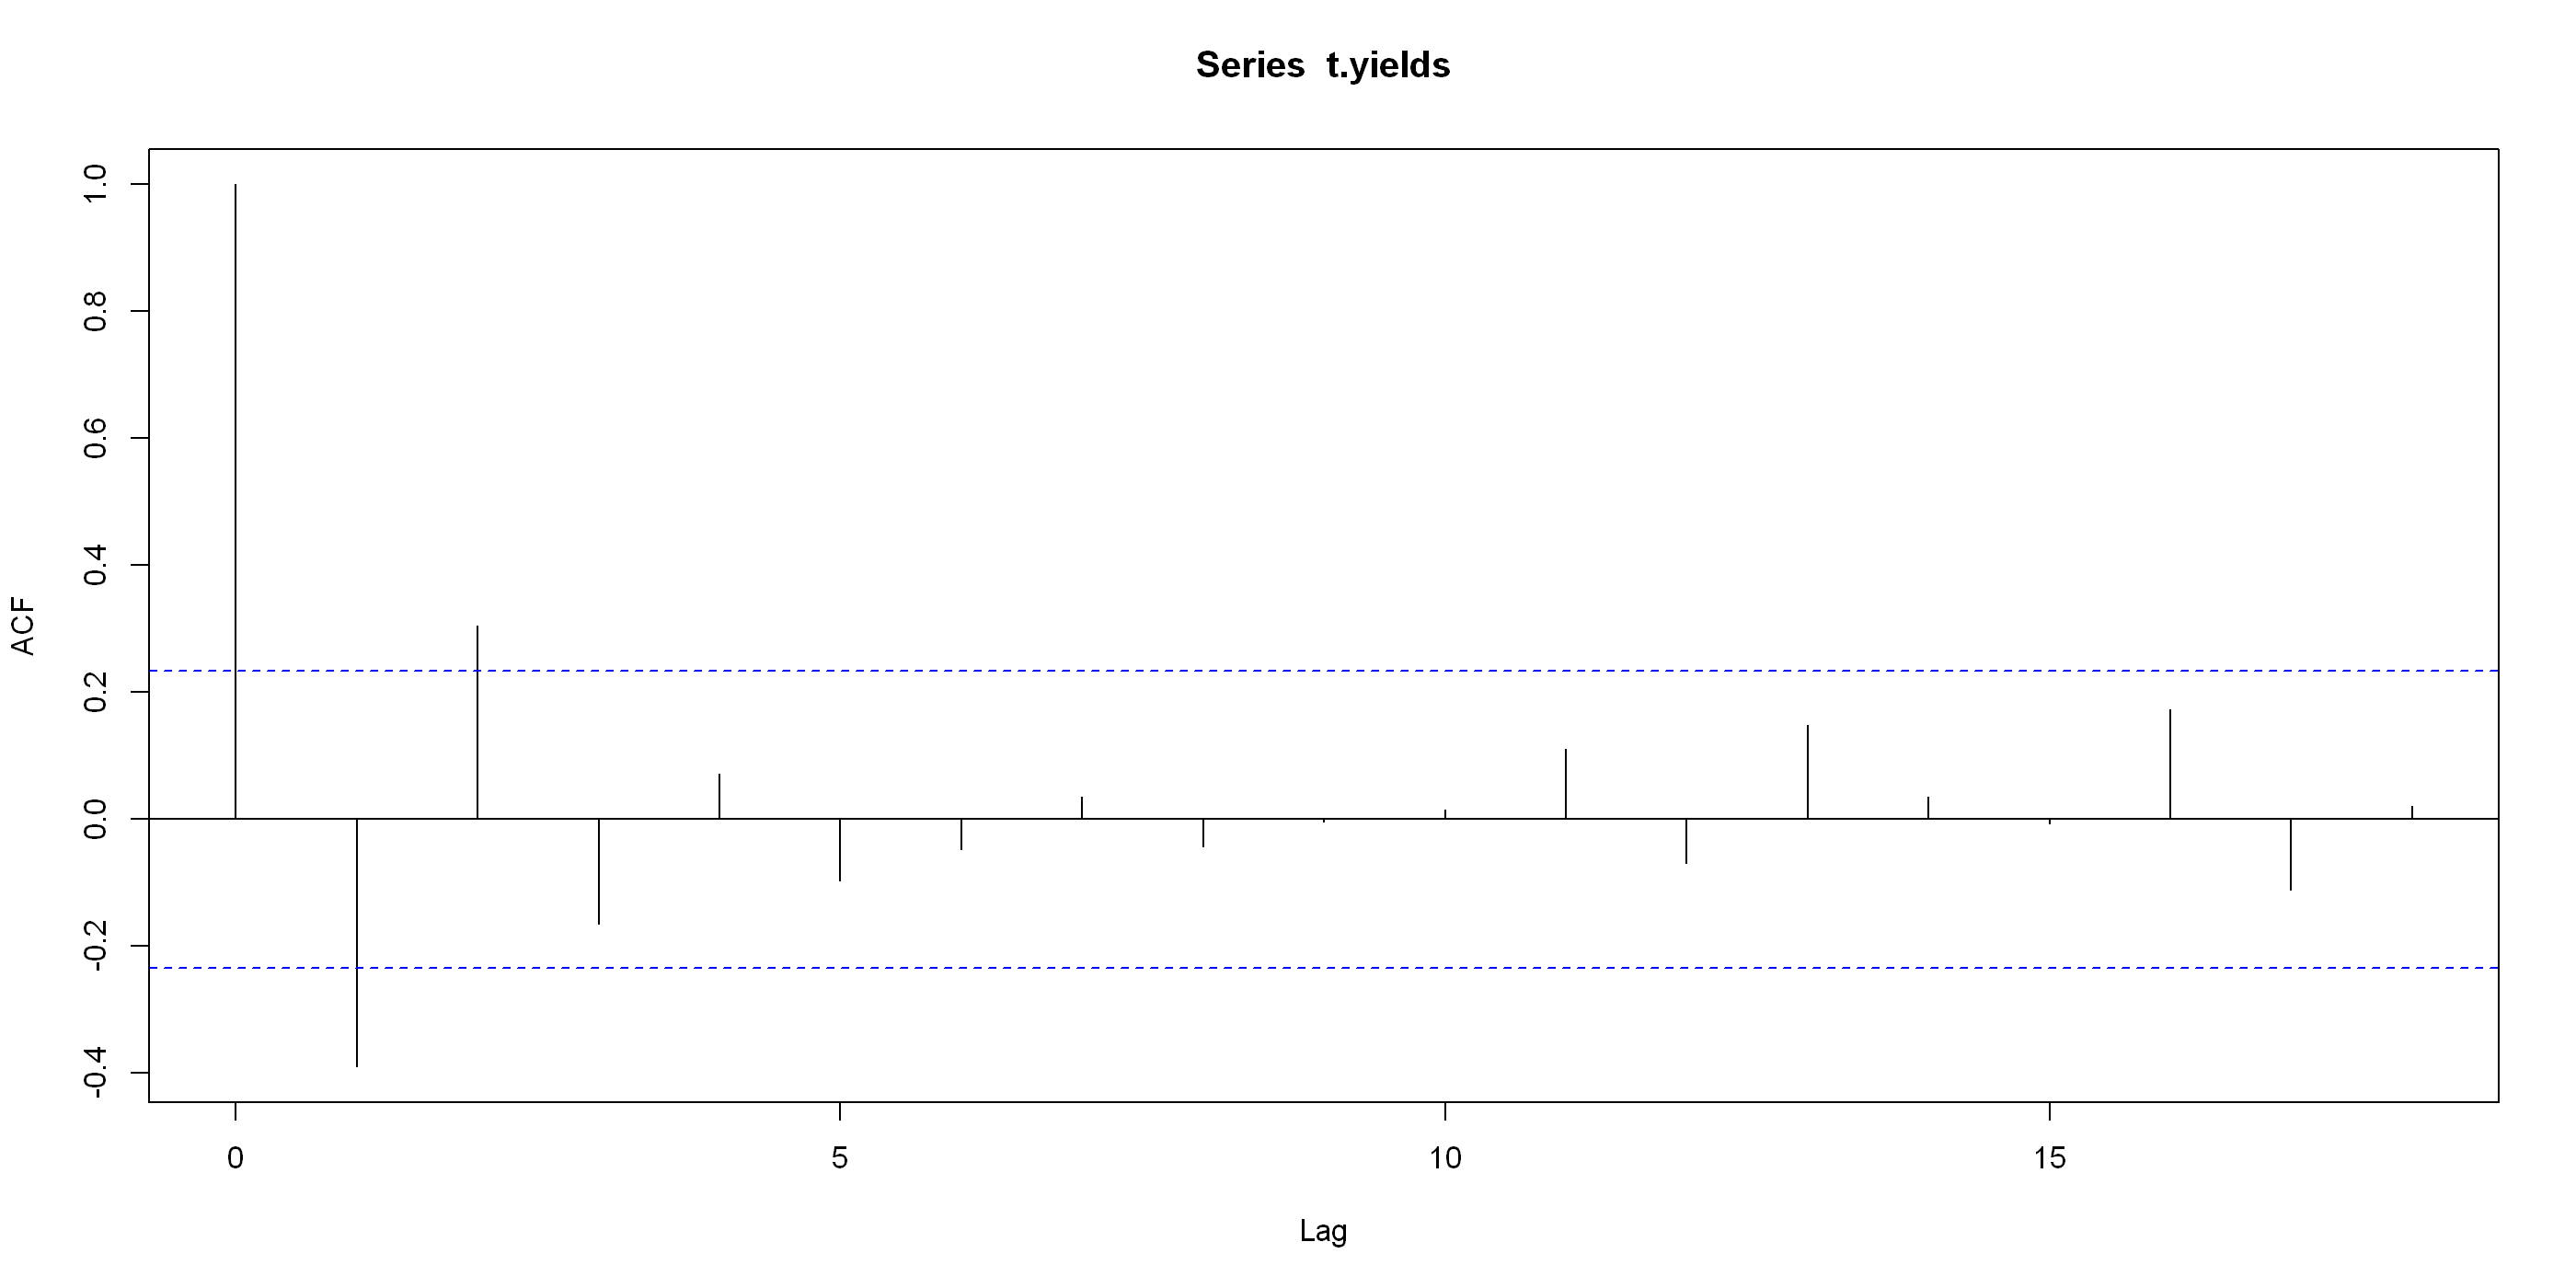

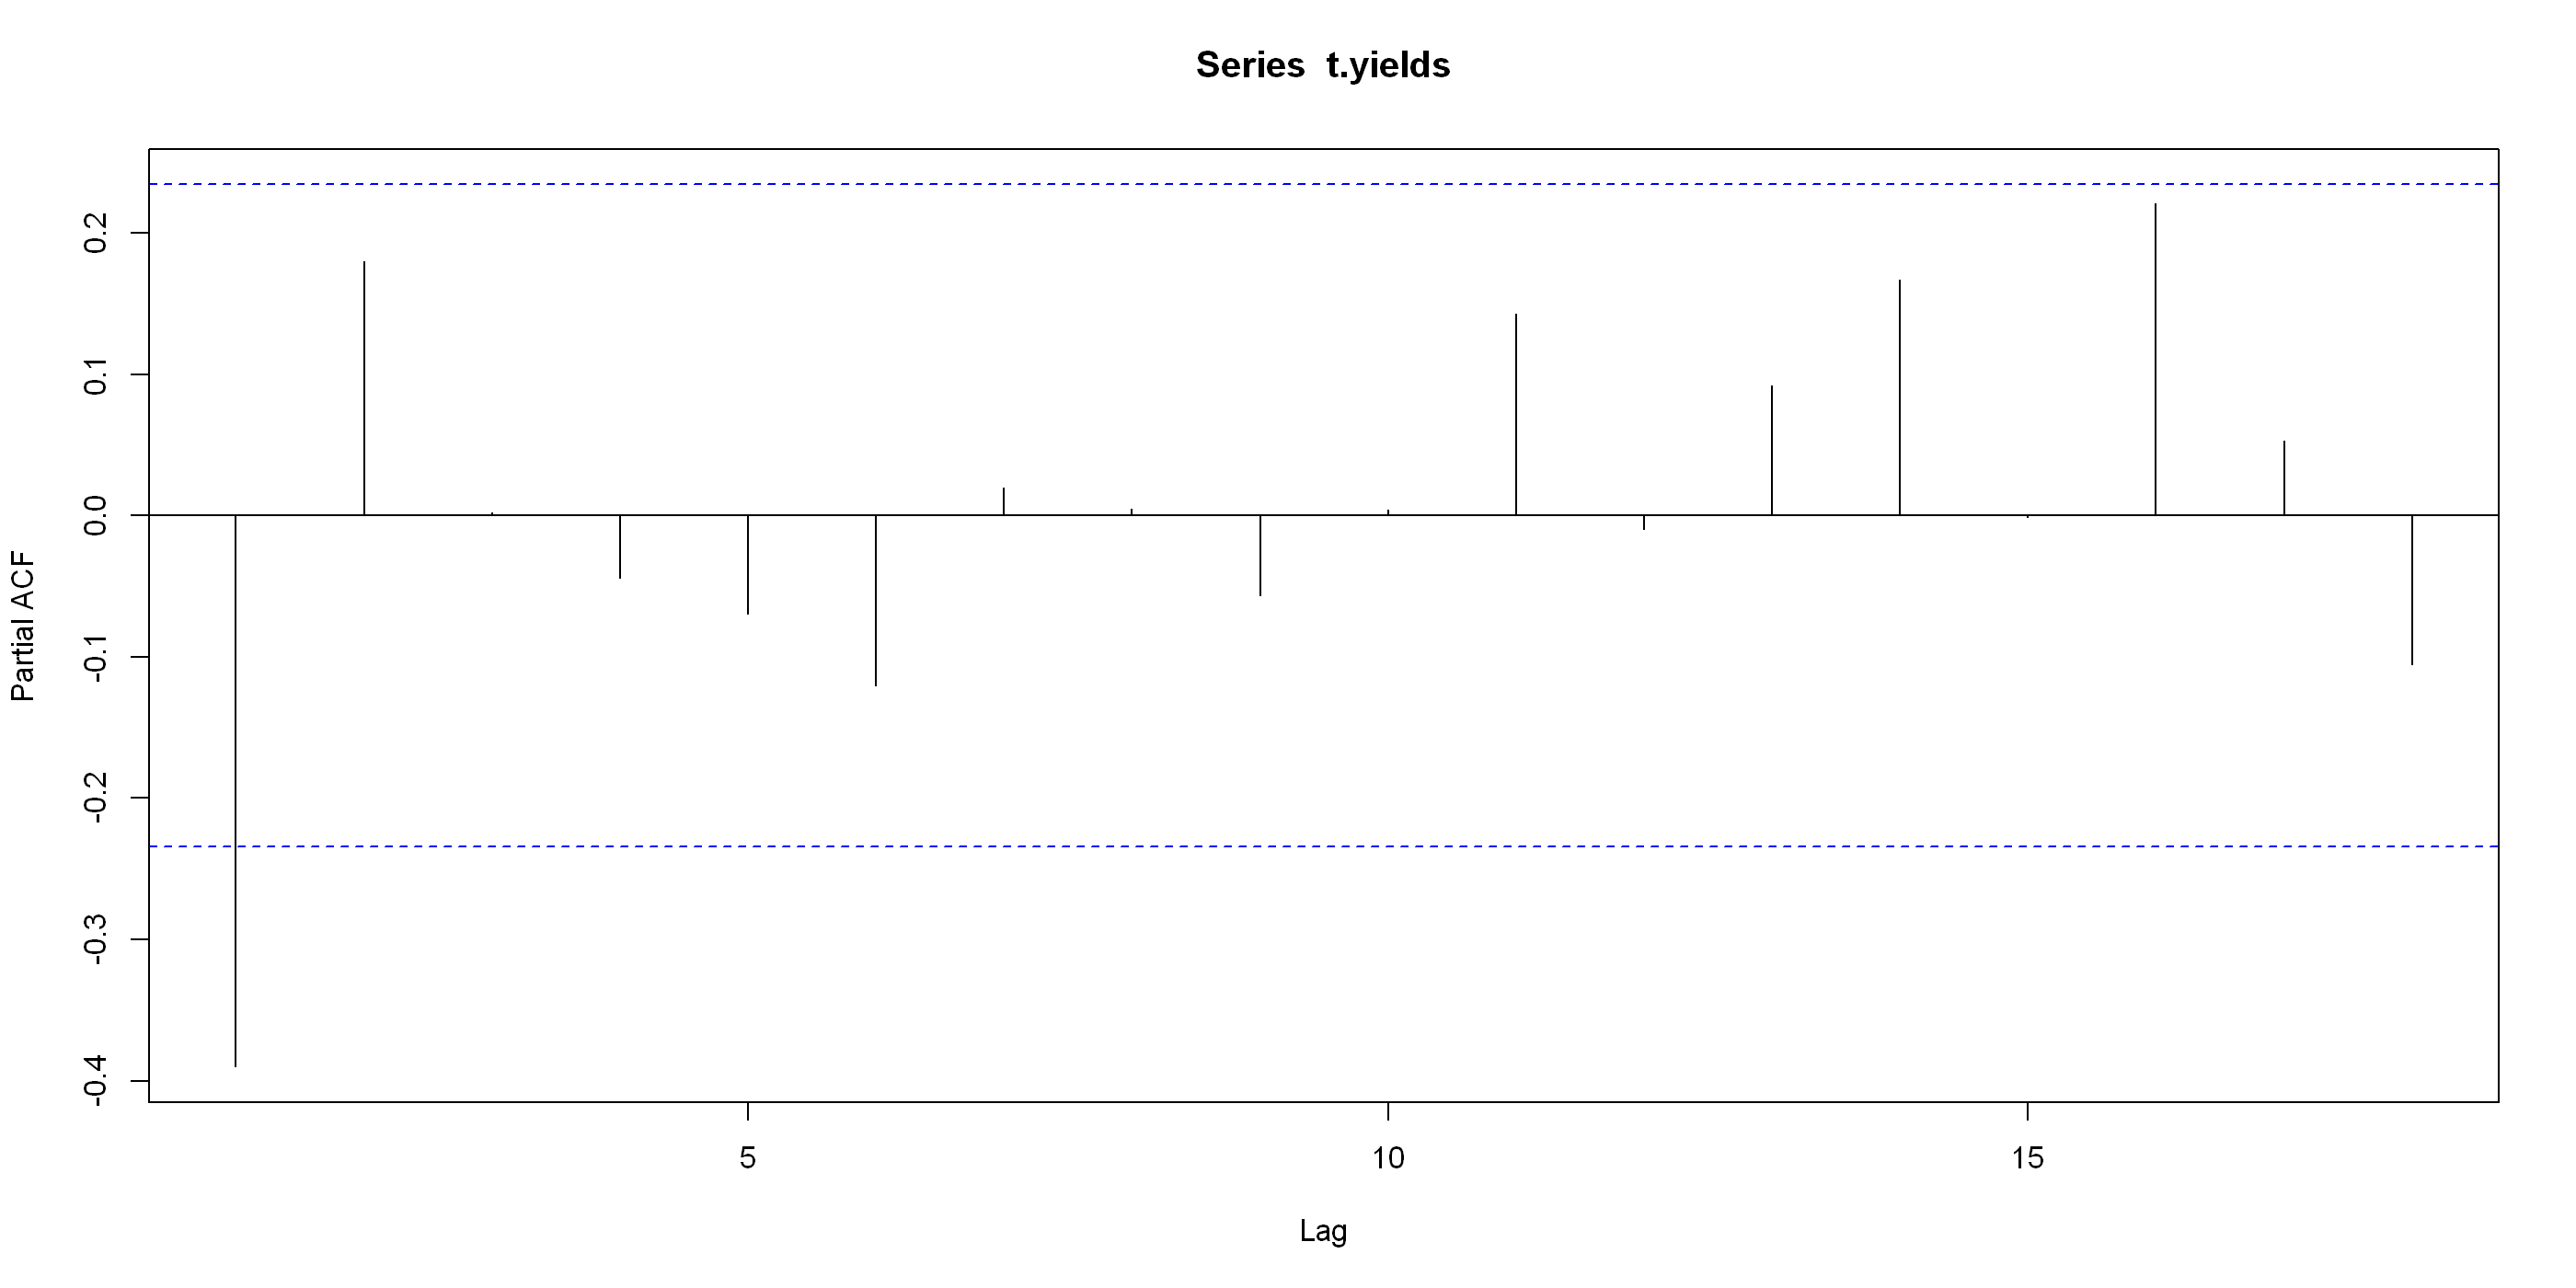

In [491]:
acf(t.yields)
pacf(t.yields)

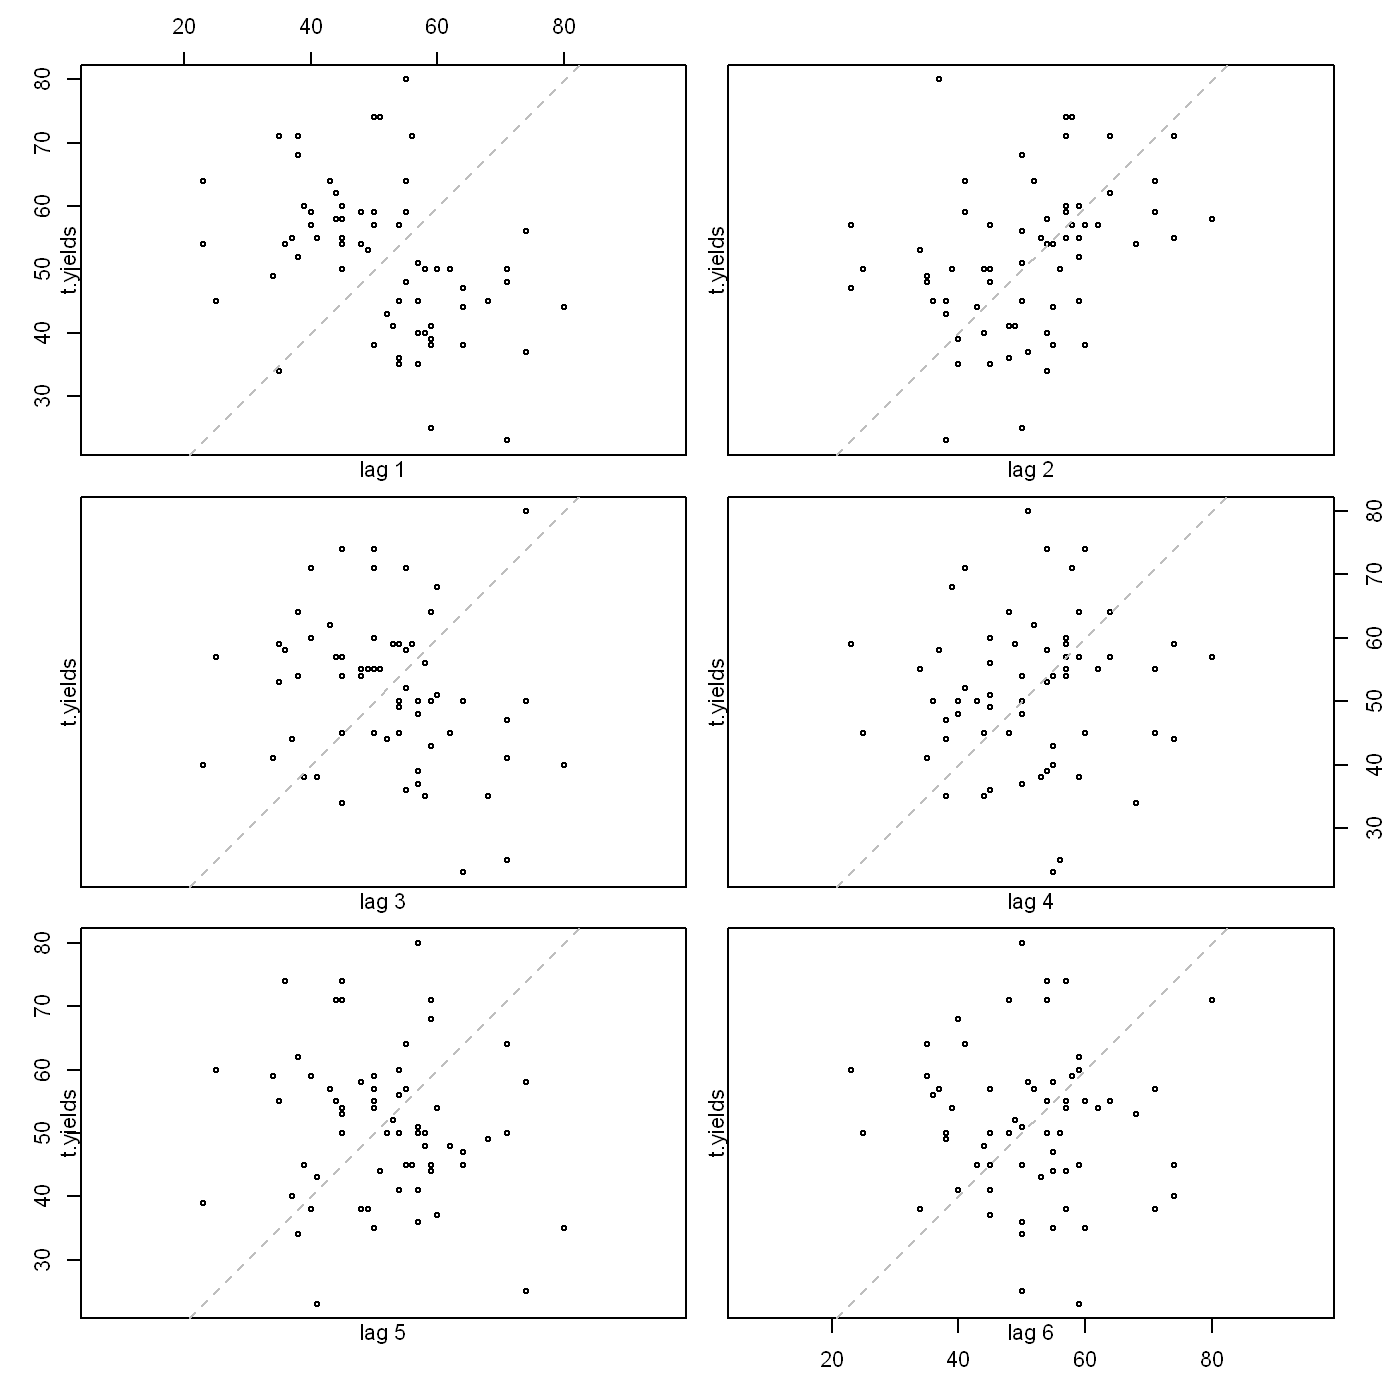

In [625]:
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 300)

n_y = length(t.yields)
lag.plot(t.yields,lags = 6,do.lines = FALSE)
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


As can be seen there is no serial dependence, though there is a slight PACF at lag 1, it is probable that it appears significant for the bounds are not adjusted.

##### 3.4.c

[1] 45.82300 53.39432
[1] 48.33877 53.91838


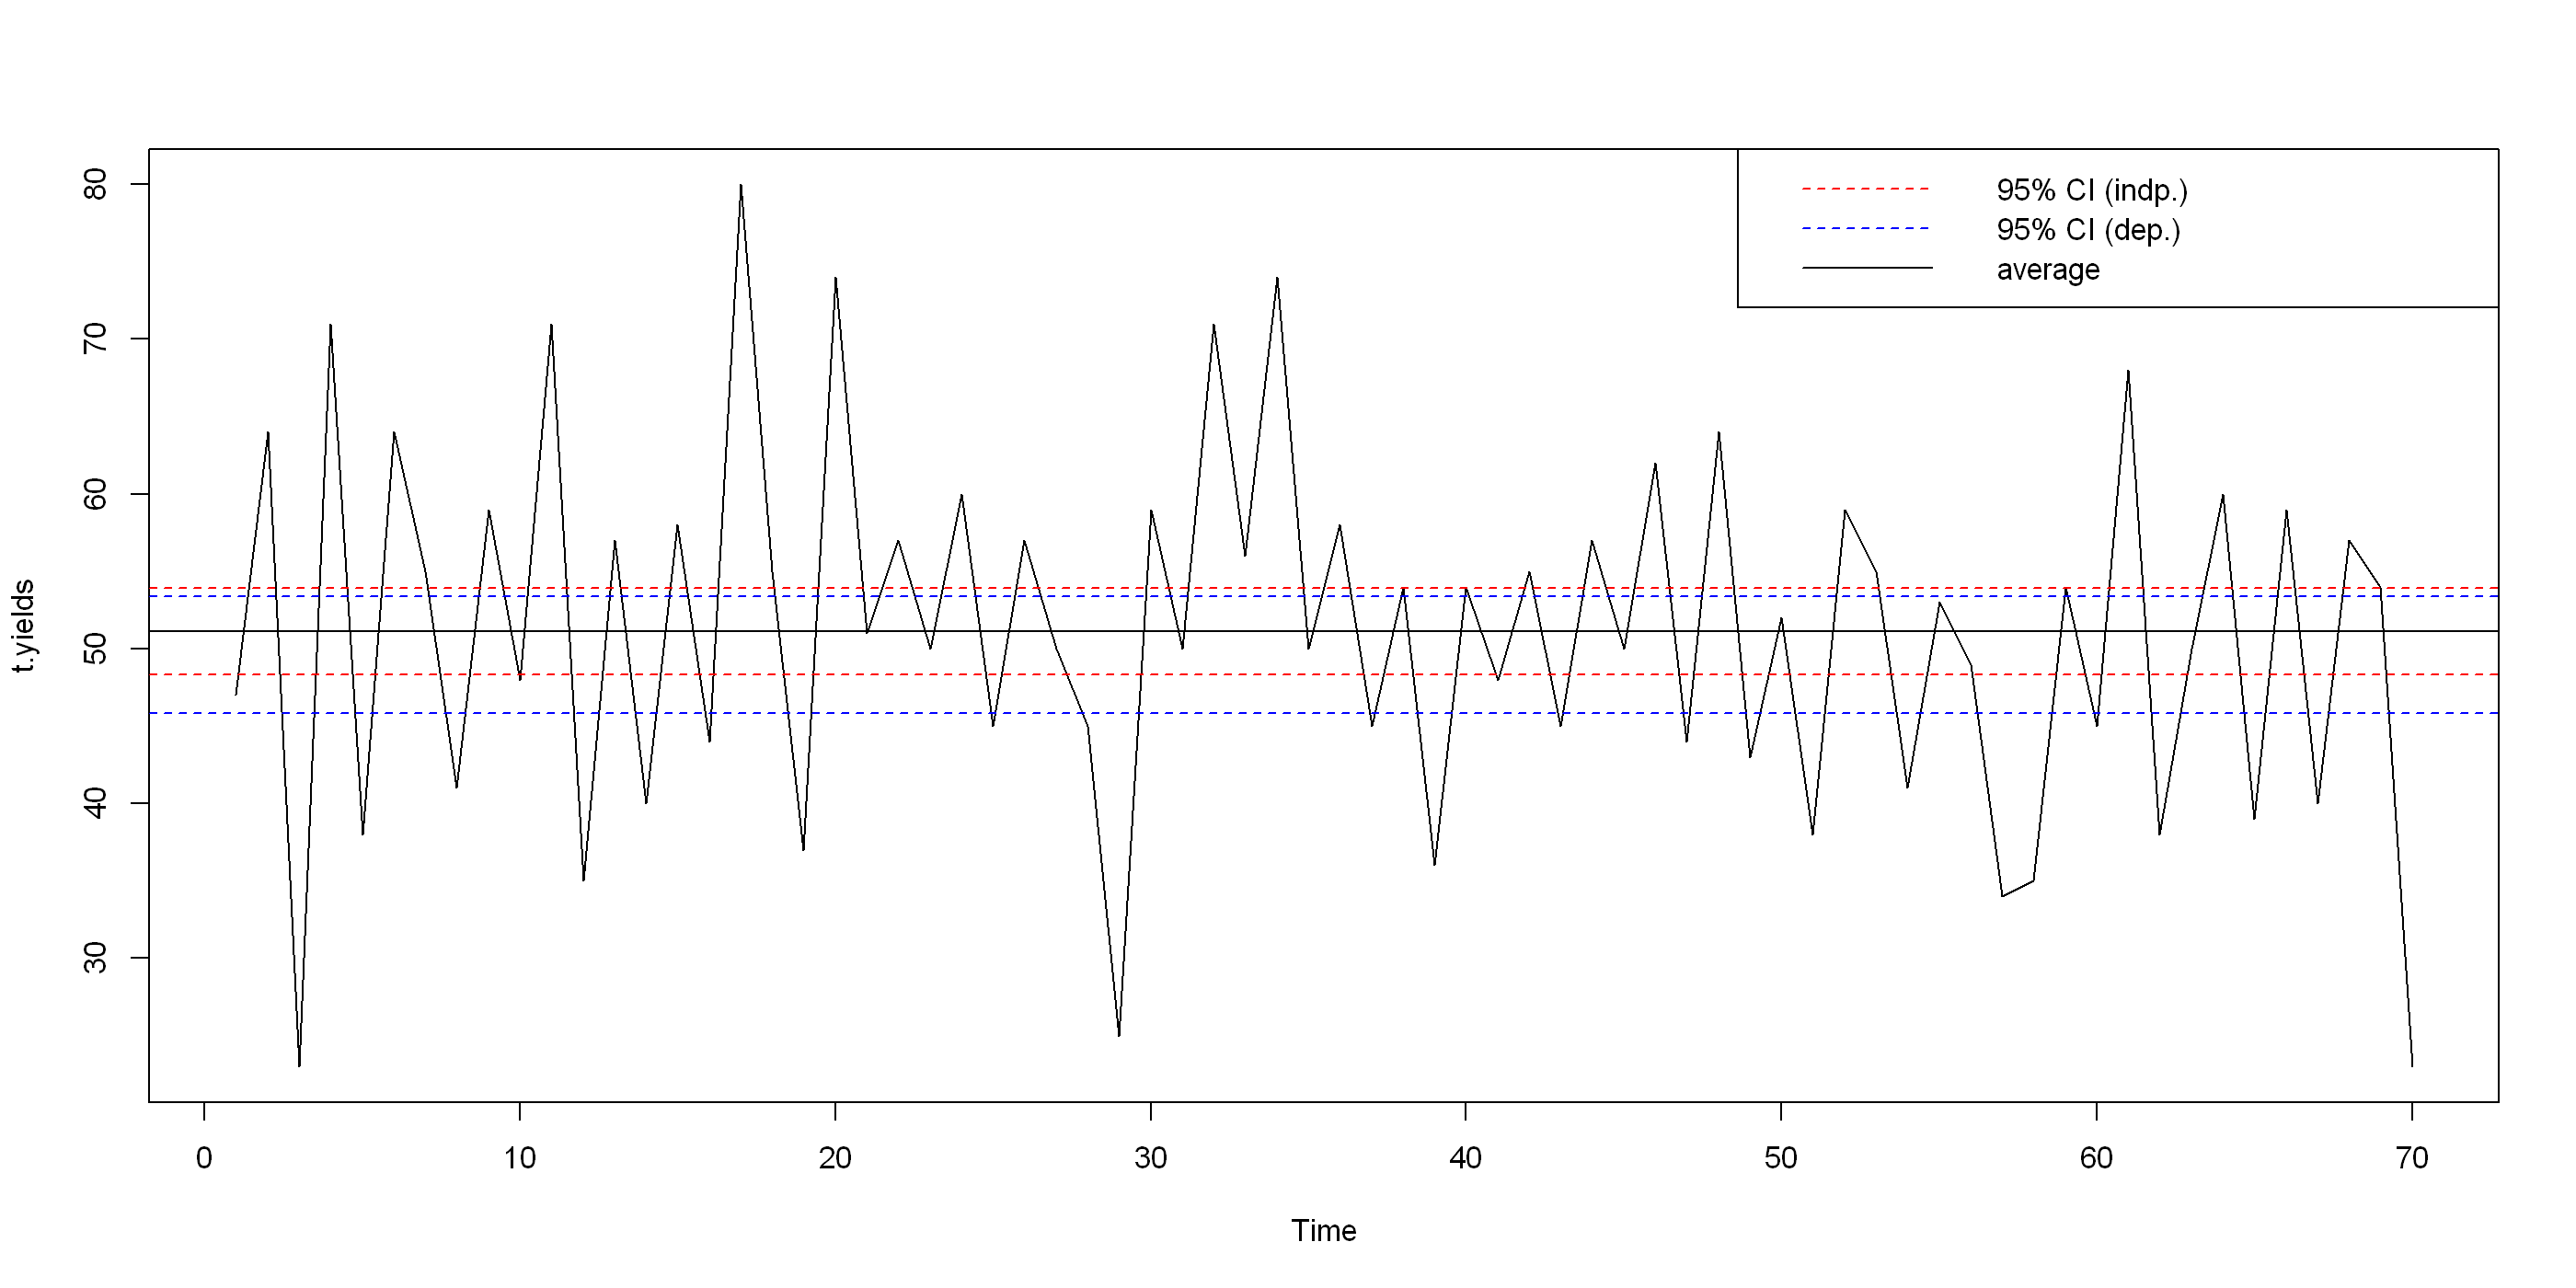

In [627]:
ci_ind = c(mu_hat-sqrt(var(t.yields)/n_y)*qnorm(0.975),mu_hat+sqrt(var(t.yields)/n_y)*qnorm(0.975))
gamma_0_hat = acf(t.yields,type="covariance",plot = FALSE)$acf[1]

corr = 0.0
acf_vals =(acf(t.yields,plot=F))$acf
for(i in range(round(10*log10(n_y))))
{
    corr <- corr + (n_y-i)*acf_vals[i]
}
ci_dep = c(mu_hat-sqrt(gamma_0_hat/n_y**2 *(n+2*corr))*qnorm(0.975),mu_hat+sqrt(gamma_0_hat/n_y**2 *(n_y+2*corr))*qnorm(0.975))

plot(t.yields)
abline(h=ci_ind,col="red",lty="dashed")
abline(h=ci_dep,col="blue",lty="dashed")
abline(h=mu_hat)
legend("topright",legend = c("95% CI (indp.)","95% CI (dep.)","average"),col=c("red","blue","black"),lty = c("dashed","dashed","solid"),lwd = 1)

print(ci_dep)
print(ci_ind)